In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import re
import numpy as np

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9"
}

city_areas = {
    "kochi":['edappally', 'panampilly-nagar', 'kacheripady', 'vyttila',  'fort-kochi', 'palarivattom', 'kakkanad', 'mg-road'],
    "bangalore": ["indiranagar", "whitefield", "koramangala", "btm", "hsr"],
    "chennai": ["t-nagar", "velachery", "adyar", "porur", "nungambakkam"],
    "varanasi": ['lanka', 'sigra', 'bhelupur',  'assi-ghat', 'chetganj', 'nadesar', 'dashaswmedh-road', 'mahmoorganj'],
    "trivandrum": ['kannanthura', 'kazhakkoottam', 'ambalamukku', 'kesavadasapuram', 'kumarapuram', 'palayam', 'thycaud', 'kulathoor'],
    "thrissur": ['poothole', 'ayyanthole', 'guruvayur-locality', 'chalakudy', 'irinjalakuda-locality', 'peringavu', 'kizhakkumpattukara', 'puzhakkal'],
    "pune": ['kothrud', 'wakad', 'hinjawadi', 'kalyani-nagar', 'kharadi','viman-nagar'],
    "puducherry": ['auroville', 'gandhinagar', 'mudaliarpet', 'kottukuppam', 'heritage-town', 'lawspet', 'white-town', 'mg-road'],
    "ooty":['anna-nagar', 'kandal', 'marlimund', 'elk-hill', 'fern-hill', 'thalayathimund'],
    "mysore": ['vijay-nagar', 'chamrajpura', 'doora', 'mandi-mohalla', 'jayalakhsmipuram', 'bannimantap', 'kuvempunagar', 'gokulam'],
    "manali": ['old-manali','aleo', 'tibetan-colony'],
    "mangalore": ['lalbagh', 'balmatta', 'kodailbail', 'hampankatta', 'kadri', 'ks-rao-nagar',  'kankanady', 'attavar'],
    "madurai": ['kk-nagar', 'arrapalayam', 'iyer-bungalow', 'viswanathapuram', 'periyar', 'othakadai', 'ss-colony', 'sathamangalam'],
    "lucknow": ['gomti-nagar', 'hazratganj', 'aliganj', 'aashiana', 'aminabad', 'indira-nagar', 'alambagh', 'chowk'],
    "kolkata": ['park-street-area', 'sector-1-salt-lake', 'ballygunge', 'camac-street-area', 'southern-avenue', 'new-town', 'sector-5-salt-lake', 'chinar-park'],
    "goa": ['calangute', 'margao', 'vagator', 'panaji', 'arambol', 'anjuna', 'baga', 'candolim'],
    "delhi": ['connaught-place-delhi', 'rajouri-garden-delhi', 'sector-18-noida', 'golf-course-road', 'dlf-cyber-city',  'sector-29-gurgaon-gurugram', 'saket-delhi', 'dlf-phase-4'],
    "coimbatore": ['ramanathapuram', 'town-hall', 'kalapatti', 'peelamedu',  'rs-puram', 'saibaba-colony', 'gandhipuram', 'race-course'],
    "chennai": ['thuraipakkam', 'mylapore', 'alwarpet', 't-nagar', 'adyar', 'velachery', 'nungambakkam', 'anna-nagar-east'],
    "amritsar": ['town-hall', 'basant-nagar',  'ina-colony',  'lawrence-road', 'white-avenue', 'gt-road', 'kabir-park', 'ranjit-avenue'],
    "agra": ['rakabganj', 'khandari', 'tajganj', 'kamla-nagar', 'agra-cantt', 'sikandra', 'civil-lines', 'mantola'],
    "jamshedpur": ['telco-colony', 'golmuri', 'sakchi', 'bistupur', 'gamharia', 'sonari', 'mango', 'birsanagar']

}

data = []

# -----------------------------
# WIKIPEDIA
# -----------------------------
def get_wiki(city):
    try:
        url = f"https://en.wikipedia.org/wiki/{city.capitalize()}"
        res = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(res.text, "lxml")
        text = soup.get_text()

        pop = re.search(r'Population.*?(\d{1,3}(?:,\d{3})+)', text)
        area = re.search(r'Area.*?(\d{1,3}(?:,\d{3})*)\s?km', text)

        return (
            pop.group(1) if pop else None,
            area.group(1) if area else None,
            "yes" if "tourism" in text.lower() else "no",
            "yes" if "gdp" in text.lower() else "no"
        )
    except:
        return None, None, None, None


# -----------------------------
# MAIN SCRAPER
# -----------------------------
for city in city_areas:

    print(f"\nCITY: {city}")
    pop, area_km, tourism_flag, gdp_flag = get_wiki(city)

    for area in city_areas[city]:

        for page in range(1, 11):

            url = f"https://www.zomato.com/{city}/{area}-restaurants?page={page}"
            print(f"{city}-{area} Page {page} | Rows: {len(data)}")

            try:
                res = requests.get(url, headers=headers, timeout=10)

                if res.status_code != 200:
                    break

                soup = BeautifulSoup(res.text, "lxml")
                cards = soup.find_all("div", class_="jumbo-tracker")

                if not cards:
                    break

                for card in cards:
                    try:
                        name = card.find("h4")
                        name = name.text.strip() if name else None

                        cuisine = card.find("p")
                        cuisine = cuisine.text.strip() if cuisine else "Unknown"

                        # Cuisine count
                        cuisine_count = len(cuisine.split(",")) if cuisine else 0

                        # Price
                        price_tag = card.find(string=lambda t: t and "₹" in t)
                        price_text = price_tag.strip() if price_tag else None

                        cost = None
                        if price_text:
                            m = re.search(r'\d+', price_text.replace(',', ''))
                            if m:
                                cost = int(m.group())

                        # Price category
                        if cost:
                            if cost < 200:
                                price_category = "low"
                            elif cost < 500:
                                price_category = "medium"
                            else:
                                price_category = "high"
                        else:
                            price_category = None

                        # Rating
                        rating_tag = card.find(string=lambda x: x and re.match(r'^\d\.\d$', x))
                        rating = float(rating_tag) if rating_tag else None

                        # Rating category
                        if rating:
                            if rating >= 4:
                                rating_category = "excellent"
                            elif rating >= 3:
                                rating_category = "good"
                            else:
                                rating_category = "poor"
                        else:
                            rating_category = None

                        # Links & image
                        link_tag = card.find("a", href=True)
                        link = "https://www.zomato.com" + link_tag['href'] if link_tag else None

                        img_tag = card.find("img")
                        image = img_tag['src'] if img_tag else None

                        text_blob = card.get_text().lower()

                        # Type
                        restaurant_type = "quick_bite" if "quick" in text_blob else "casual"

                        # Features
                        order_online = "yes" if "order online" in text_blob else "no"
                        book_table = "yes" if "book a table" in text_blob else "no"
                        delivery_available = 1 if "delivery" in text_blob else 0
                        dinein_available = 1 if "dine" in text_blob else 0

                        if name:
                            data.append([
                                name, cuisine, cuisine_count,
                                cost, price_category,
                                rating, rating_category,
                                order_online, book_table,
                                delivery_available, dinein_available,
                                restaurant_type,
                                city, area,
                                pop, area_km,
                                tourism_flag, gdp_flag,
                                link, image
                            ])

                    except:
                        continue

                time.sleep(random.uniform(1, 2))

            except:
                break


# -----------------------------
# DATAFRAME
# -----------------------------
columns = [
    "name","cuisine","cuisine_count",
    "cost","price_category",
    "rating","rating_category",
    "order_online","book_table",
    "delivery_available","dinein_available",
    "restaurant_type",
    "city","area",
    "city_population","city_area_km",
    "tourism_flag","gdp_flag",
    "link","image"
]

df = pd.DataFrame(data, columns=columns)
df.to_csv("final_perfect_dataset.csv", index=False)

if df.empty:
    print("❌ No data scraped")
else:
    df.drop_duplicates(inplace=True)

print("\n✅ FINAL PERFECT DATASET CREATED")
print("Rows:", len(df))


CITY: kochi
kochi-edappally Page 1 | Rows: 0
kochi-edappally Page 2 | Rows: 9
kochi-edappally Page 3 | Rows: 18
kochi-edappally Page 4 | Rows: 27
kochi-edappally Page 5 | Rows: 36
kochi-edappally Page 6 | Rows: 45
kochi-edappally Page 7 | Rows: 54
kochi-edappally Page 8 | Rows: 63
kochi-edappally Page 9 | Rows: 72
kochi-edappally Page 10 | Rows: 81
kochi-panampilly-nagar Page 1 | Rows: 90
kochi-panampilly-nagar Page 2 | Rows: 99
kochi-panampilly-nagar Page 3 | Rows: 108
kochi-panampilly-nagar Page 4 | Rows: 117
kochi-panampilly-nagar Page 5 | Rows: 126
kochi-panampilly-nagar Page 6 | Rows: 135
kochi-panampilly-nagar Page 7 | Rows: 144
kochi-panampilly-nagar Page 8 | Rows: 153
kochi-panampilly-nagar Page 9 | Rows: 162
kochi-panampilly-nagar Page 10 | Rows: 171
kochi-kacheripady Page 1 | Rows: 180
kochi-kacheripady Page 2 | Rows: 189
kochi-kacheripady Page 3 | Rows: 198
kochi-kacheripady Page 4 | Rows: 207
kochi-kacheripady Page 5 | Rows: 216
kochi-kacheripady Page 6 | Rows: 225
kochi-k

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/final_dataset.csv")

In [3]:
df.shape

(13185, 20)

In [4]:
df.head()

,name,cuisine,cuisine_count,cost,price_category,rating,rating_category,order_online,book_table,delivery_available,dinein_available,restaurant_type,city,area,city_population,city_area_km,tourism_flag,gdp_flag,link,image
0,Kubaba,"Biryani, Mandi, Arabian",3,1000.0,high,4.4,excellent,Yes,Yes,1,1,casual,kochi,edappally,"677,381",88,yes,yes,https://www.zomato.com/kochi/kubaba-edappally/...,NaN
1,Kochi Kitchen - Kochi Marriott Hotel,"South Indian, Asian, North Indian, Continental...",6,2500.0,high,4.6,excellent,Yes,Yes,1,1,casual,kochi,edappally,"677,381",88,yes,yes,https://www.zomato.com/kochi/kochi-kitchen-koc...,NaN
2,Fress Trees Garden Cafe,"Continental, Pizza, Beverages, Asian, Burger, ...",6,600.0,high,4.5,excellent,Yes,No,1,1,casual,kochi,edappally,"677,381",88,yes,yes,https://www.zomato.com/kochi/fress-trees-garde...,NaN
3,Yaacht Kitchen,"Kerala, South Indian, Continental, Oriental, A...",8,1500.0,high,4.2,excellent,Yes,No,1,1,casual,kochi,edappally,"677,381",88,yes,yes,https://www.zomato.com/kochi/yaacht-kitchen-er...,NaN
4,Punjab Grill,"North Indian, Kebab, Biryani, Mughlai",4,1700.0,high,4.4,excellent,No,Yes,1,1,casual,kochi,edappally,"677,381",88,yes,yes,https://www.zomato.com/kochi/punjab-grill-edap...,NaN


In [5]:
df.tail()

,name,cuisine,cuisine_count,cost,price_category,rating,rating_category,order_online,book_table,delivery_available,dinein_available,restaurant_type,city,area,city_population,city_area_km,tourism_flag,gdp_flag,link,image
13180,New Facilities,"North Indian, Street Food",2,250.0,medium,3.9,good,Yes,Yes,1,1,casual,jamshedpur,birsanagar,"629,659",224,yes,no,https://www.zomato.com/jamshedpur/new-faciliti...,NaN
13181,Pizza Hut,"Pizza, Fast Food, Desserts, Beverages",4,300.0,medium,4.1,excellent,No,No,1,1,casual,jamshedpur,birsanagar,"629,659",224,yes,no,https://www.zomato.com/jamshedpur/pizza-hut-sa...,NaN
13182,Haridra - By DeHamray,"North Indian, Italian, Japanese, Continental, ...",8,1500.0,high,4.7,excellent,Yes,Yes,1,1,casual,jamshedpur,birsanagar,"629,659",224,yes,no,https://www.zomato.com/jamshedpur/haridra-by-d...,NaN
13183,Hasapi,"Continental, North Indian, Chinese, Sushi, Sea...",6,1000.0,high,4.5,excellent,No,Yes,1,1,casual,jamshedpur,birsanagar,"629,659",224,yes,no,https://www.zomato.com/jamshedpur/hasapi-sakch...,NaN
13184,Kadhi Patta - Pure Veg Restaurant,"North Indian, South Indian",2,800.0,high,4.5,excellent,No,No,1,1,casual,jamshedpur,birsanagar,"629,659",224,yes,no,https://www.zomato.com/jamshedpur/kadhi-patta-...,NaN


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(5059, 20)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5059 entries, 0 to 13180
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                5059 non-null   object 
 1   cuisine             4976 non-null   object 
 2   cuisine_count       5059 non-null   int64  
 3   cost                5057 non-null   float64
 4   price_category      5057 non-null   object 
 5   rating              4518 non-null   float64
 6   rating_category     4518 non-null   object 
 7   order_online        5059 non-null   object 
 8   book_table          5059 non-null   object 
 9   delivery_available  5059 non-null   int64  
 10  dinein_available    5059 non-null   int64  
 11  restaurant_type     5059 non-null   object 
 12  city                5059 non-null   object 
 13  area                5059 non-null   object 
 14  city_population     4680 non-null   object 
 15  city_area_km        4680 non-null   object 
 16  tourism_fl

In [9]:
df.columns

Index(['name', 'cuisine', 'cuisine_count', 'cost', 'price_category', 'rating',
       'rating_category', 'order_online', 'book_table', 'delivery_available',
       'dinein_available', 'restaurant_type', 'city', 'area',
       'city_population', 'city_area_km', 'tourism_flag', 'gdp_flag', 'link',
       'image'],
      dtype='object')

In [10]:
df.describe()

,cuisine_count,cost,rating,delivery_available,dinein_available,image
count,5059.000000,5057.000000,4518.000000,5059.000000,5059.000000,0.0
mean,5.246689,1308.315207,4.312793,0.999209,0.999209,NaN
std,2.314281,728.897187,0.337954,0.028111,0.028111,NaN
min,0.000000,150.000000,3.000000,0.000000,0.000000,NaN
25%,3.000000,800.000000,4.100000,1.000000,1.000000,NaN
50%,5.000000,1200.000000,4.400000,1.000000,1.000000,NaN
75%,8.000000,1700.000000,4.500000,1.000000,1.000000,NaN
max,8.000000,6000.000000,4.900000,1.000000,1.000000,NaN


In [ ]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))


Column: name
name
Barbeque Nation                  54
Pind Balluchi                    42
Chinese Wok                      37
The Vibe                         33
Chicking                         33
                                 ..
O2 cafe & dining                  1
Pandit Bhojanalya                 1
Mom & Mirchi                      1
Berco's - If You Love Chinese     1
Jetty                             1
Name: count, Length: 549, dtype: int64

Column: cuisine
cuisine
NaN                                                                              83
Chinese                                                                          72
North Indian, BBQ, Kebab, Biryani                                                50
Mandi, Arabian                                                                   39
Arabian, Biryani, Chinese, Mandi, South Indian, North Indian, Shake, Desserts    35
                                                                                 ..
North Indian, Chi

In [11]:
df.drop(columns=["image"], inplace=True) # many null values

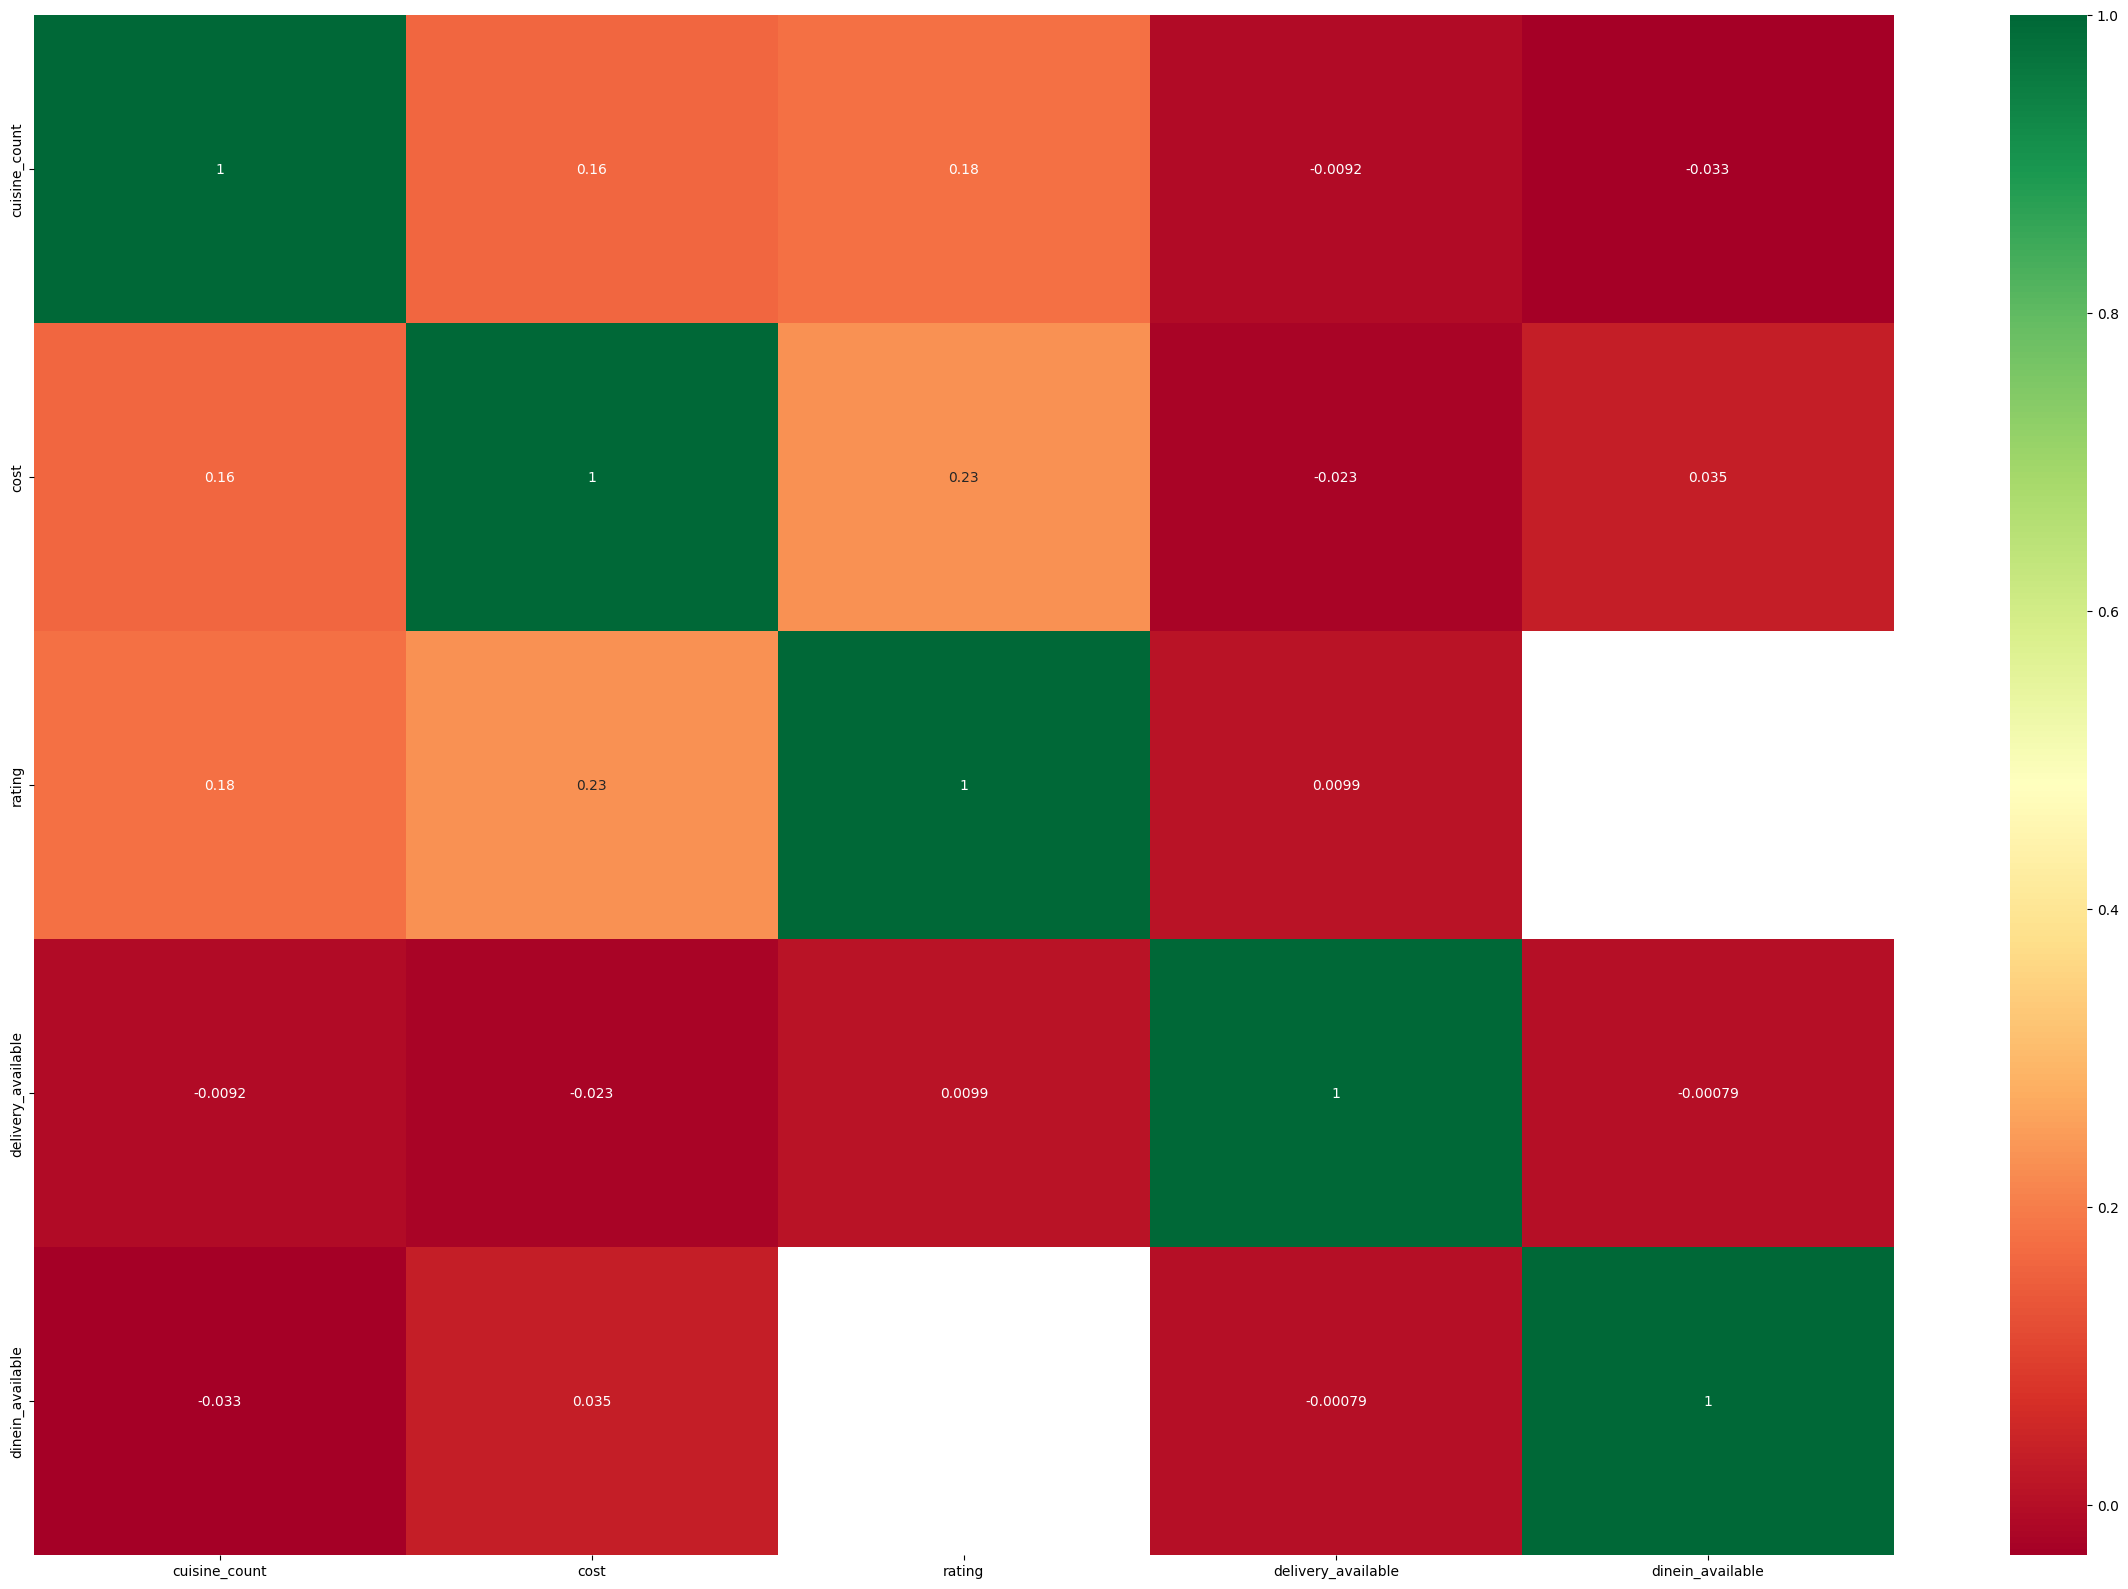

In [12]:
corrmap = df.select_dtypes(include='number').corr()
plt.figure(figsize=(30,20))
sns.heatmap(corrmap, annot=True, cmap="RdYlGn")
plt.show()

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

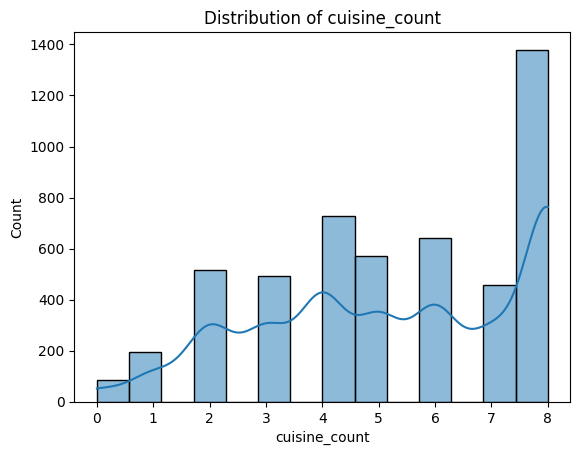

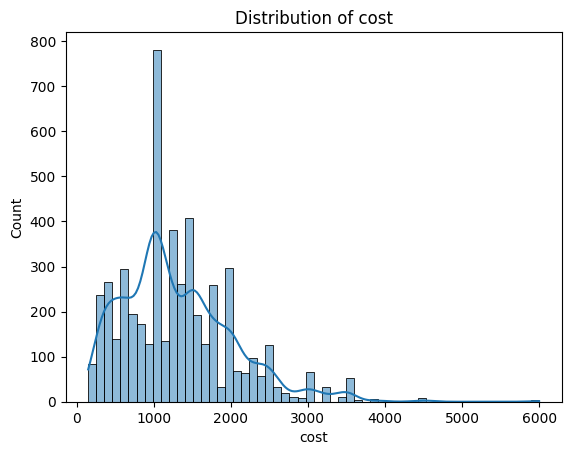

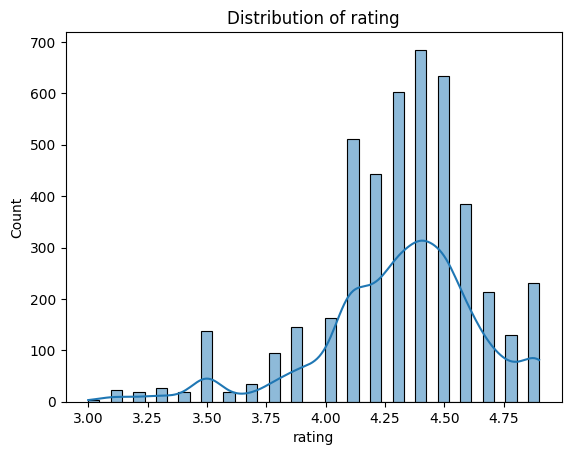

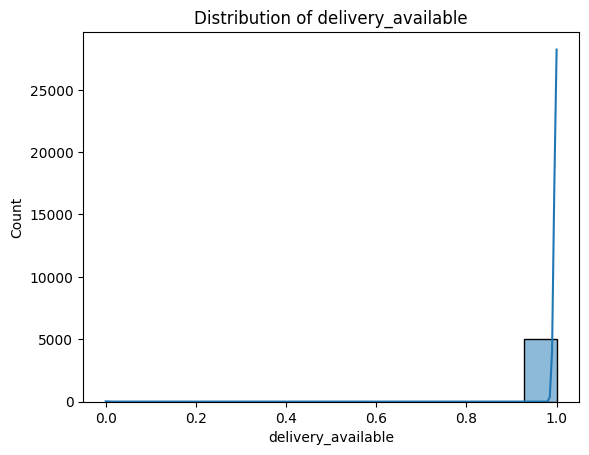

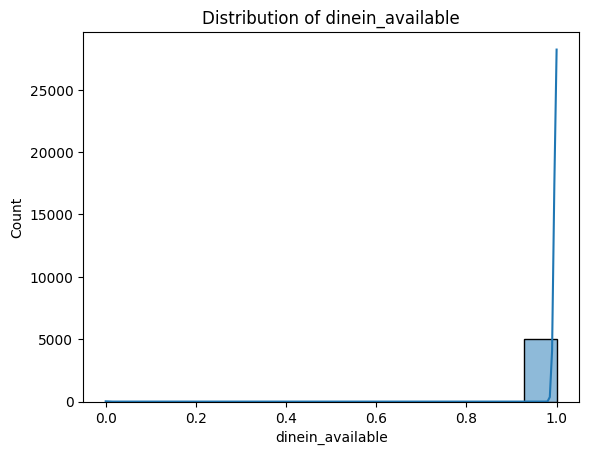

In [14]:
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

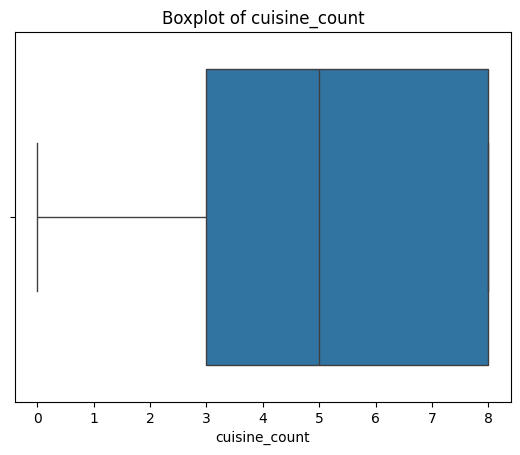

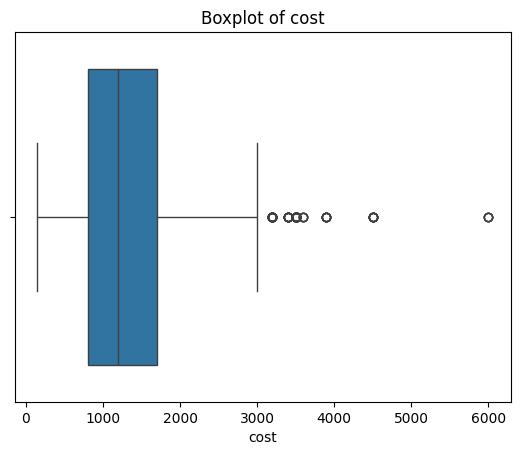

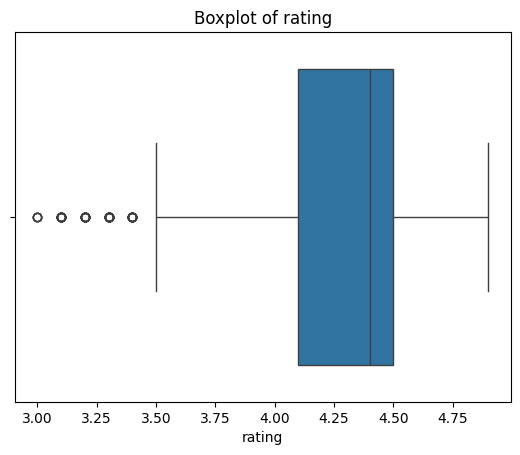

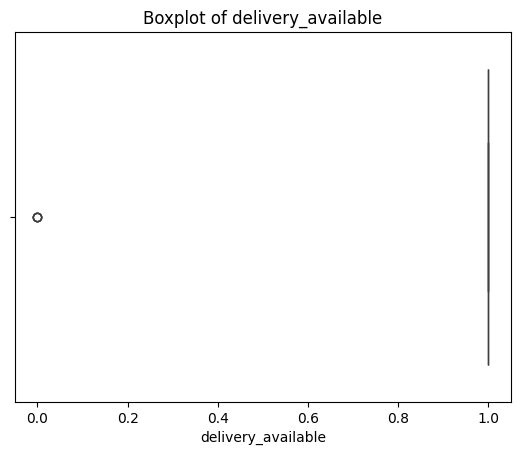

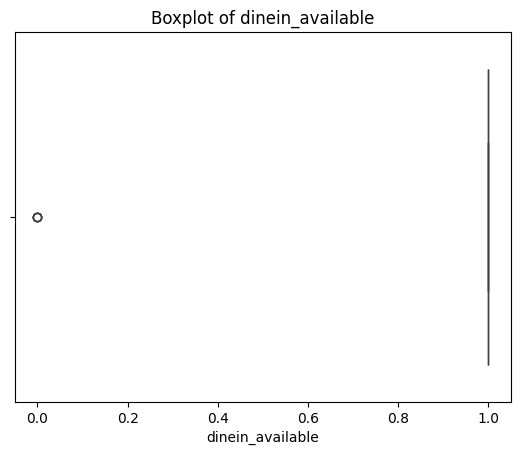

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

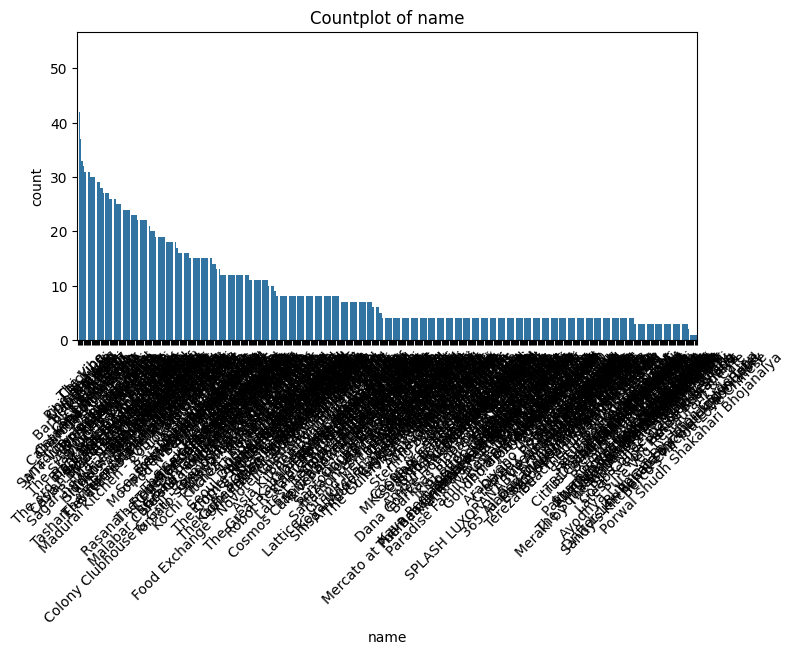

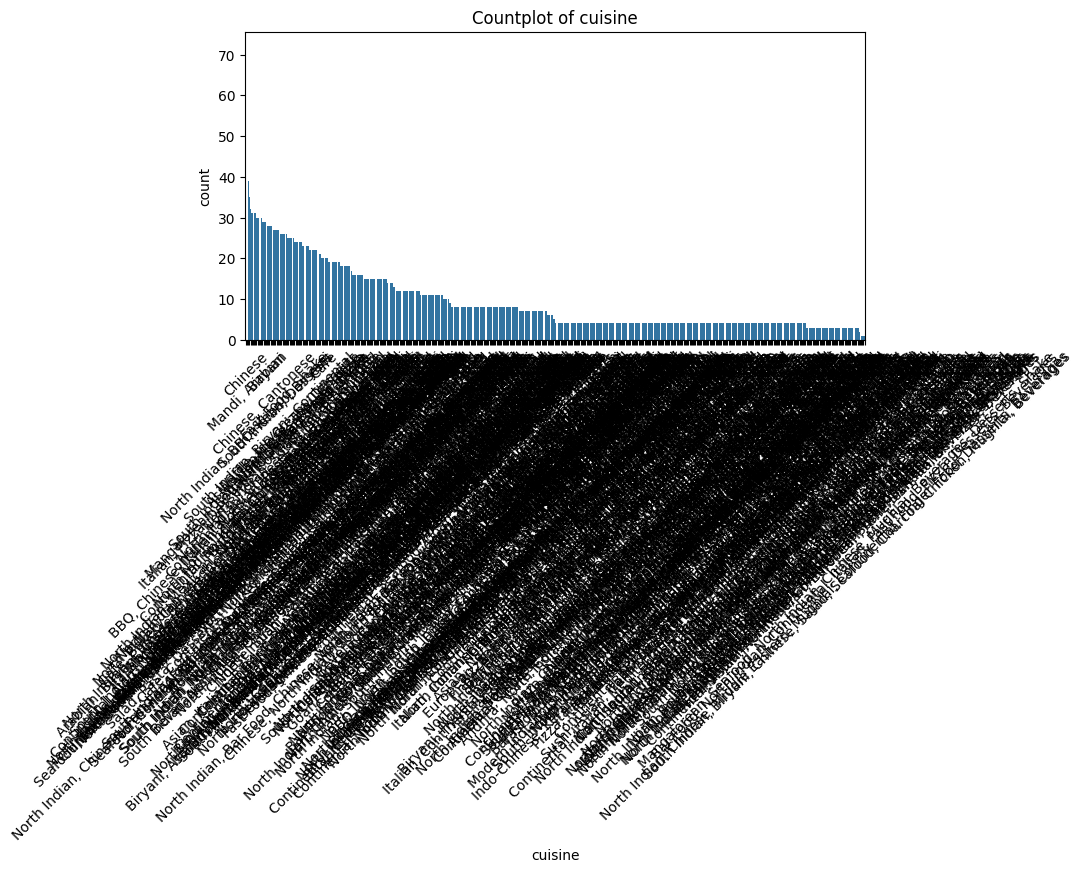

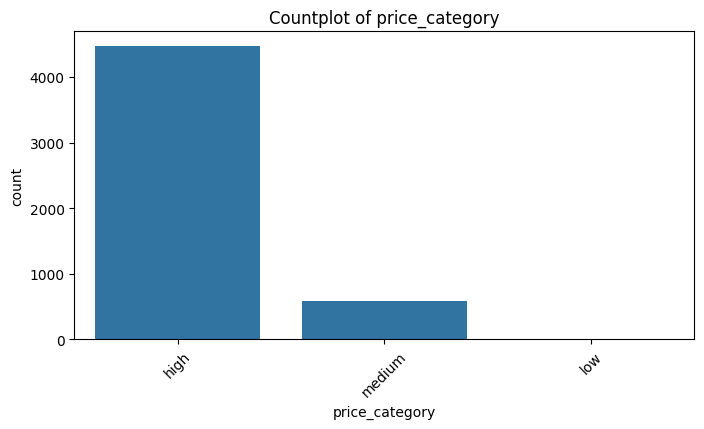

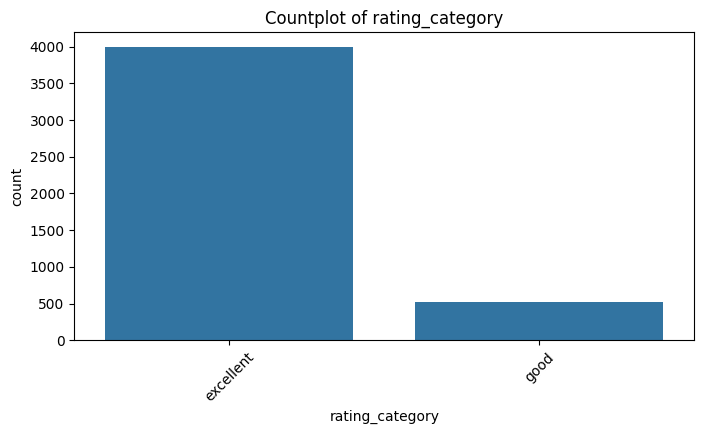

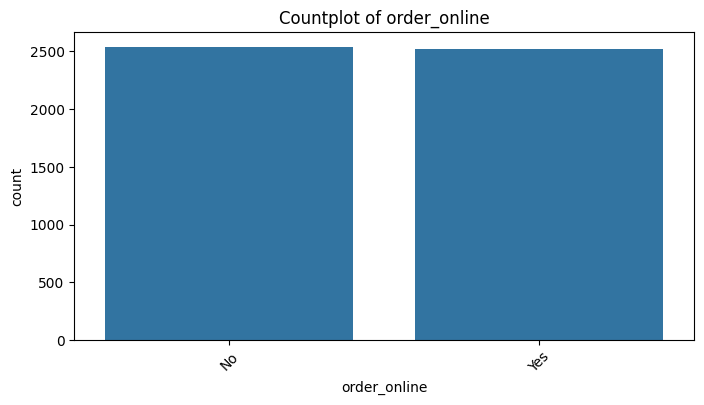

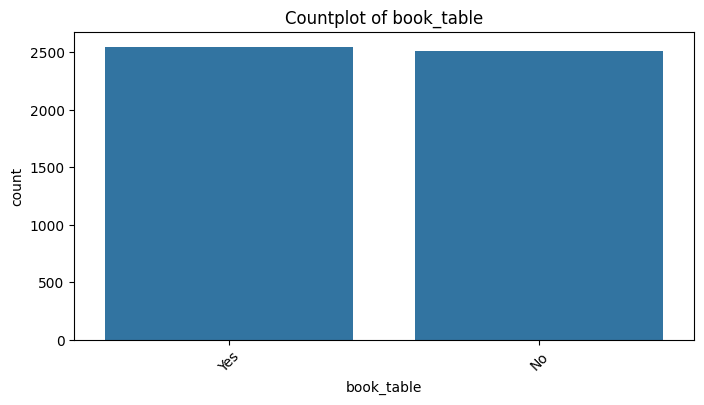

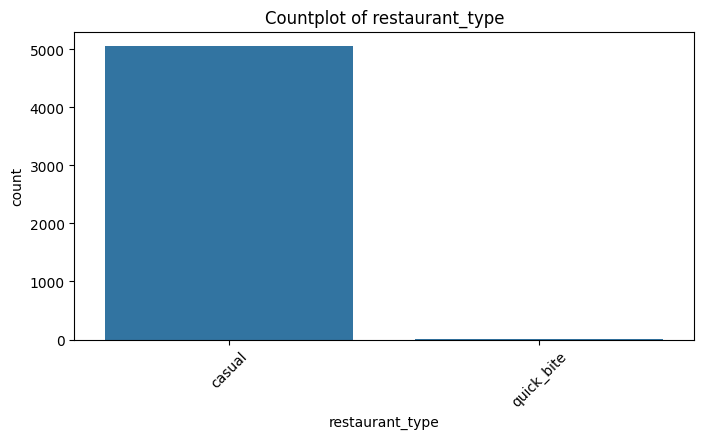

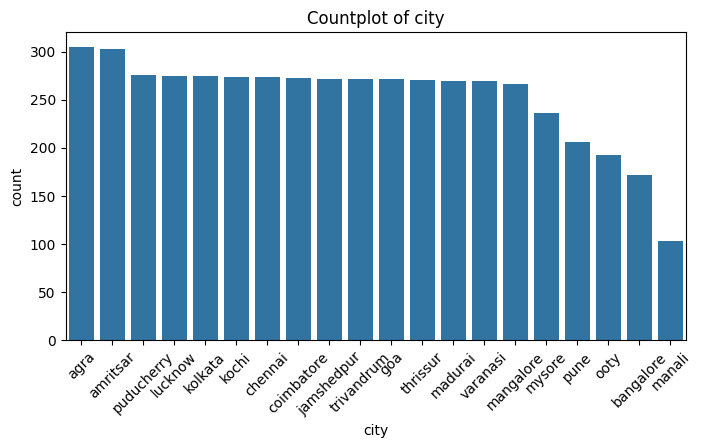

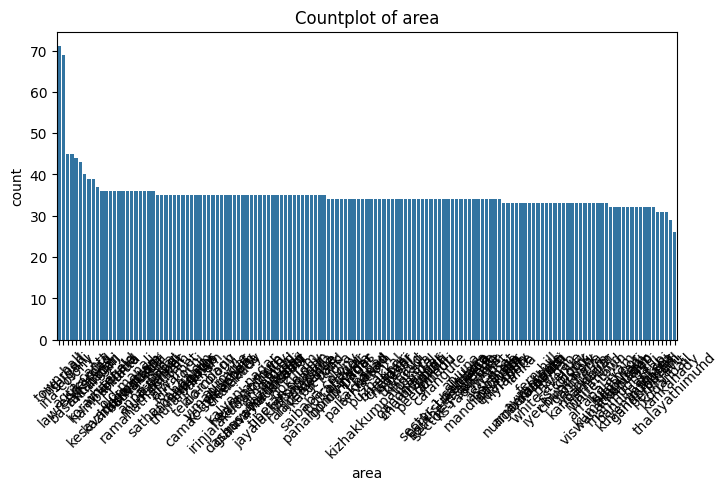

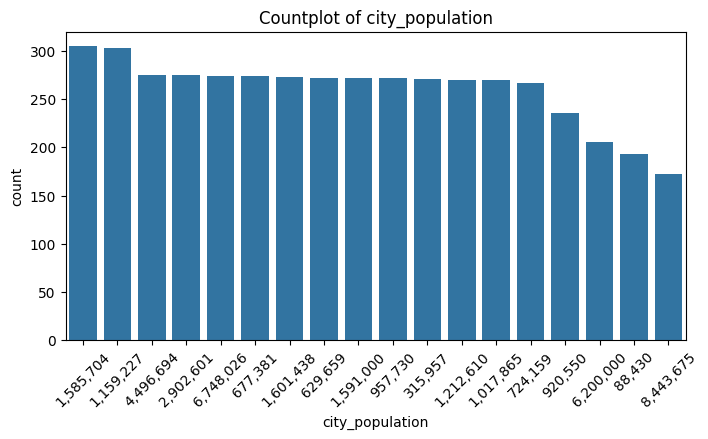

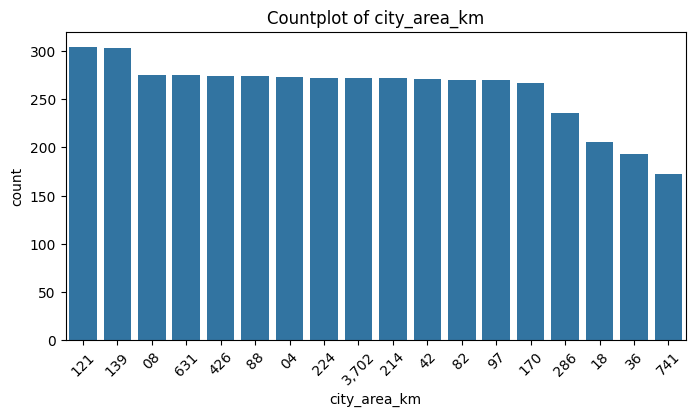

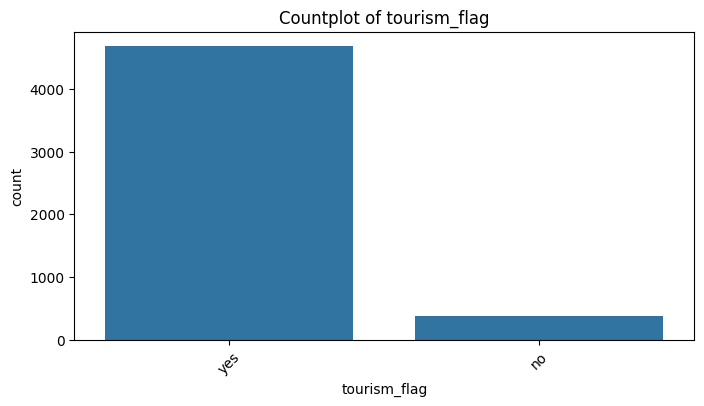

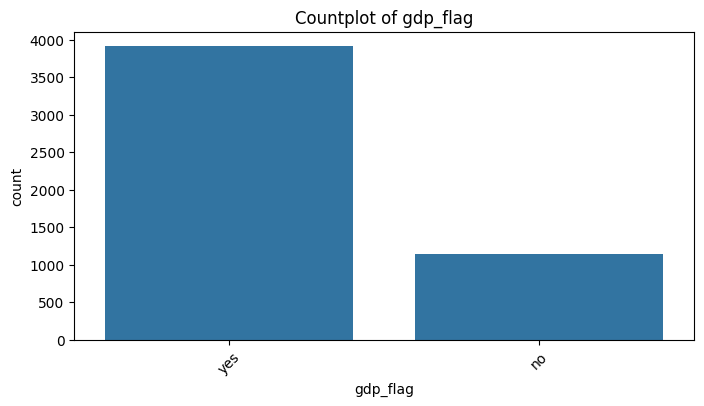

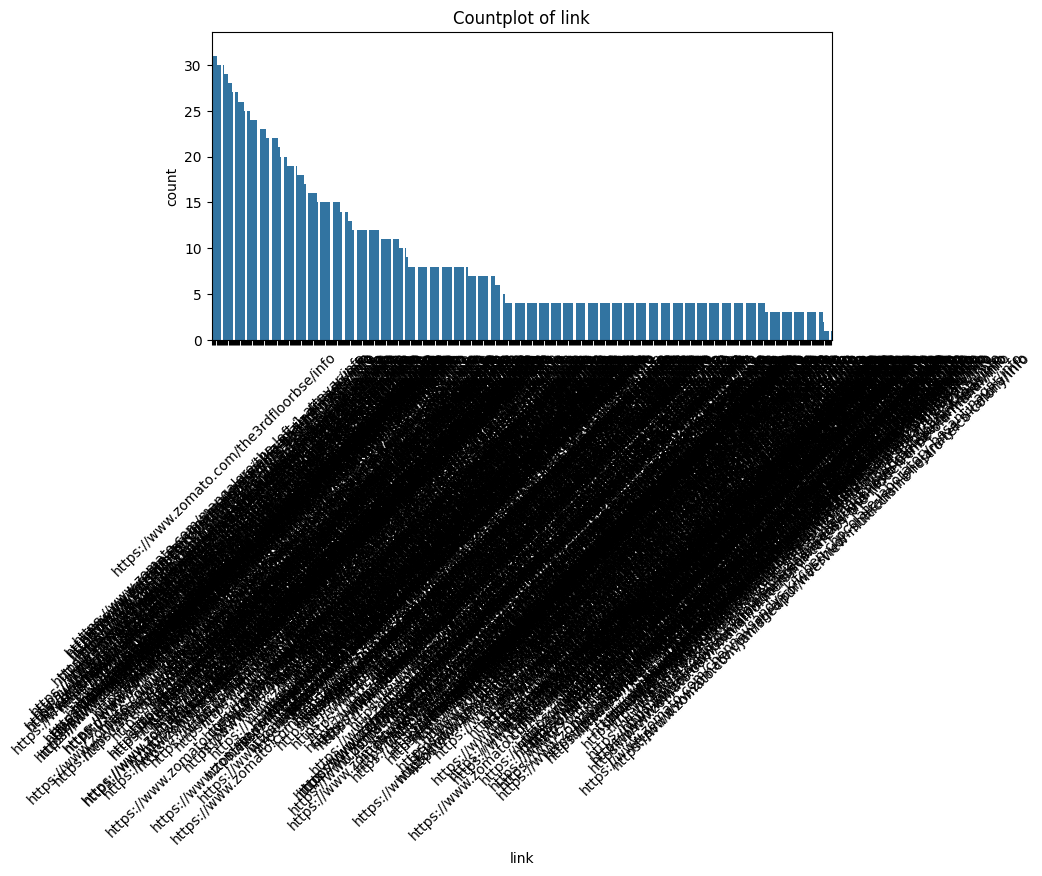

In [15]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'mg-road'),
  Text(1, 0, 'town-hall'),
  Text(2, 0, 'basant-nagar'),
  Text(3, 0, 'ina-colony'),
  Text(4, 0, 'lawrence-road'),
  Text(5, 0, 'rakabganj'),
  Text(6, 0, 'khandari'),
  Text(7, 0, 'tajganj'),
  Text(8, 0, 'agra-cantt'),
  Text(9, 0, 'sikandra')])

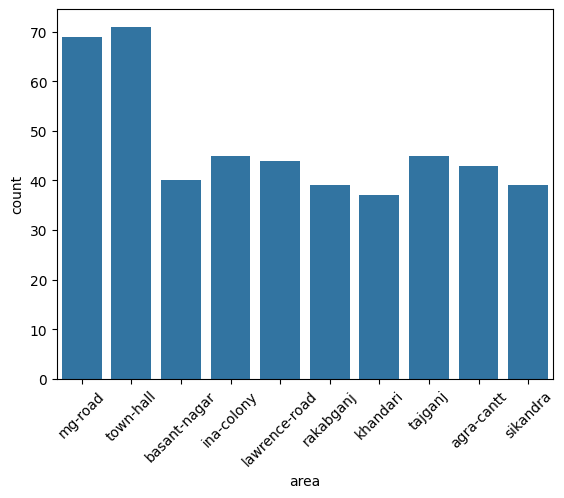

In [16]:
top_areas = df["area"].value_counts().head(10).index
sns.countplot(x=df[df["area"].isin(top_areas)]["area"])
plt.xticks(rotation=45)


In [ ]:
df["cuisine"].value_counts().head(10)

,count
cuisine,
Chinese,72
"North Indian, BBQ, Kebab, Biryani",50
"Mandi, Arabian",39
"Arabian, Biryani, Chinese, Mandi, South Indian, North Indian, Shake, Desserts",35
"North Indian, Chinese, Mediterranean, Continental, Mexican, Modern Indian",32
"Seafood, Mangalorean, Goan, South Indian, North Indian, Chinese, Desserts, Beverages",31
"BBQ, Chinese, Italian, North Indian, Fast Food, Beverages",31
"Continental, North Indian, Asian, Pasta, French, Seafood, South Indian, Beverages",31
"North Indian, Continental, Chinese, Fast Food, Desserts, Beverages, Oriental, Kebab",31


In [ ]:
df.dtypes

,0
name,object
cuisine,object
cuisine_count,int64
cost,float64
price_category,object
rating,float64
rating_category,object
order_online,object
book_table,object
delivery_available,int64


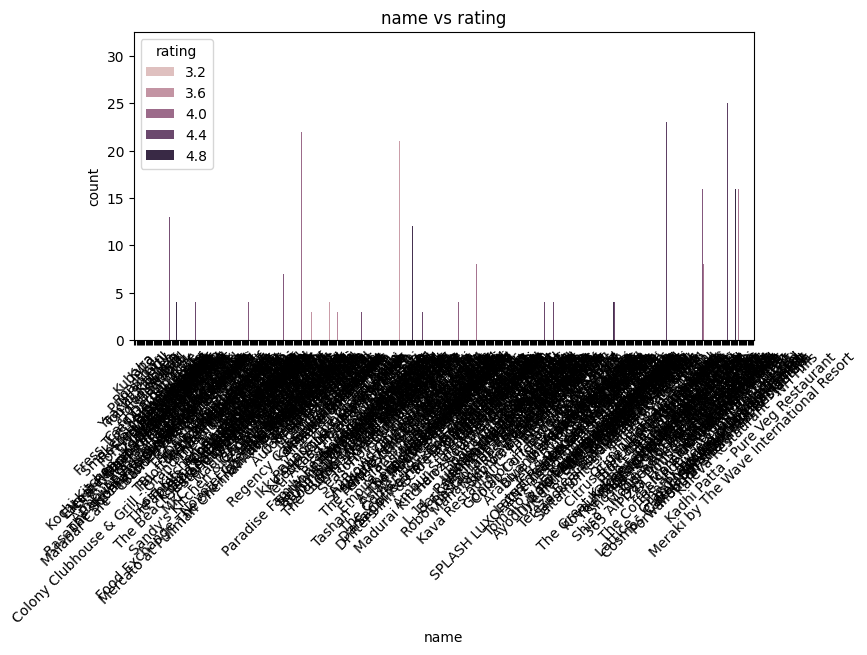

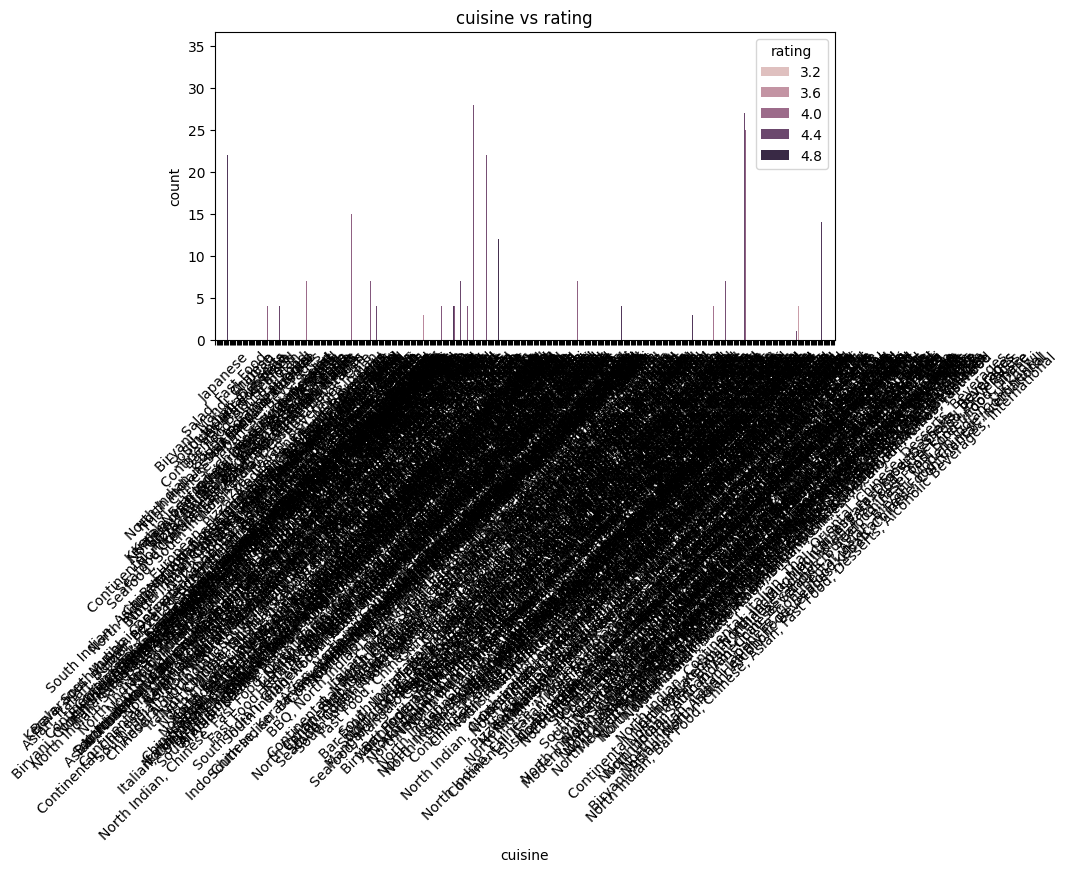

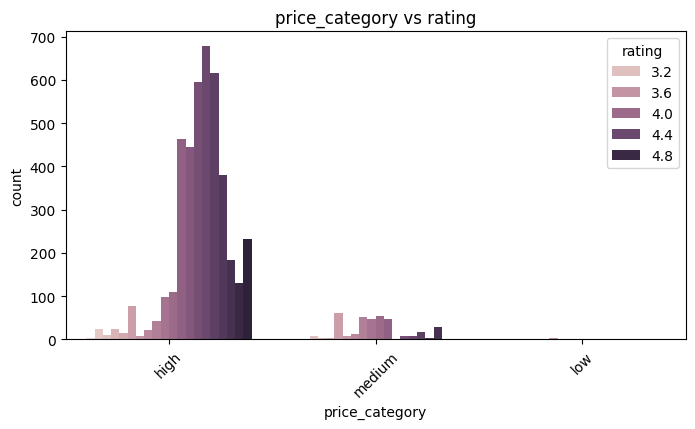

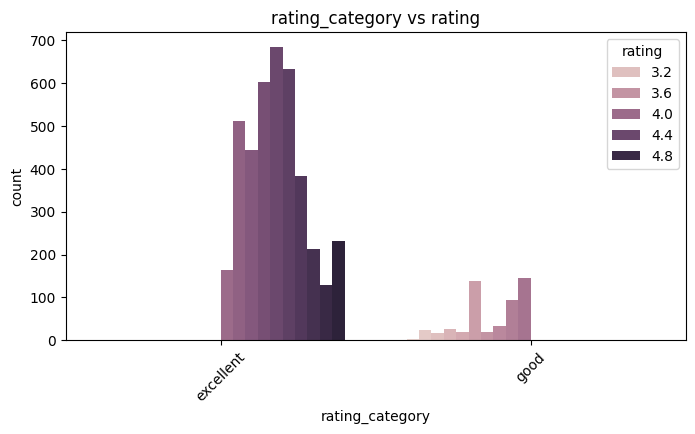

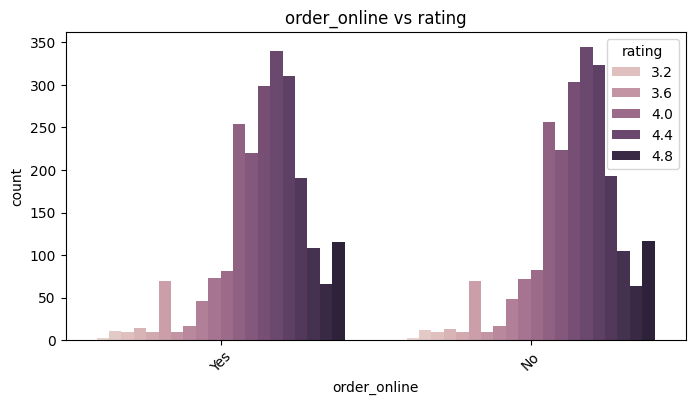

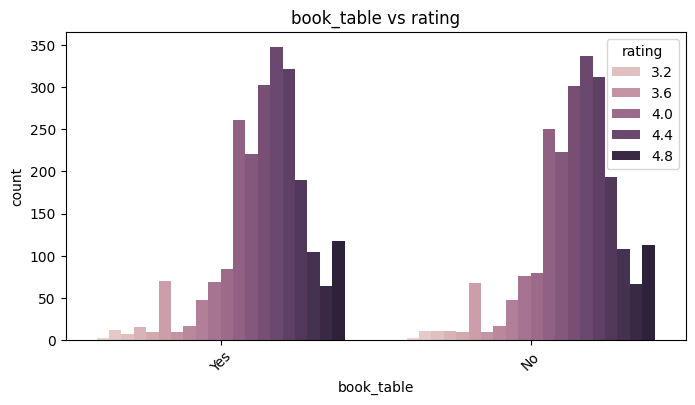

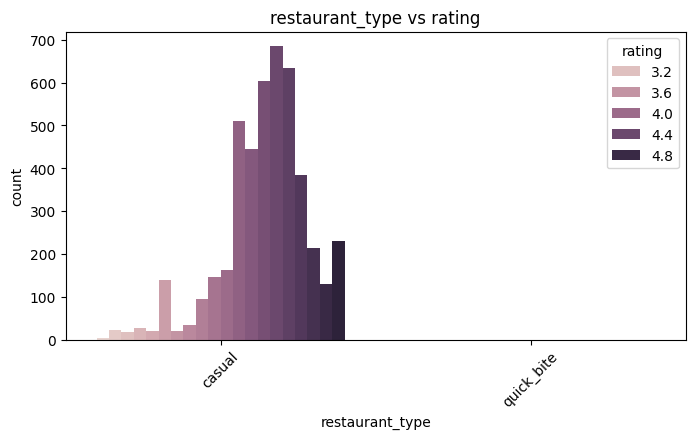

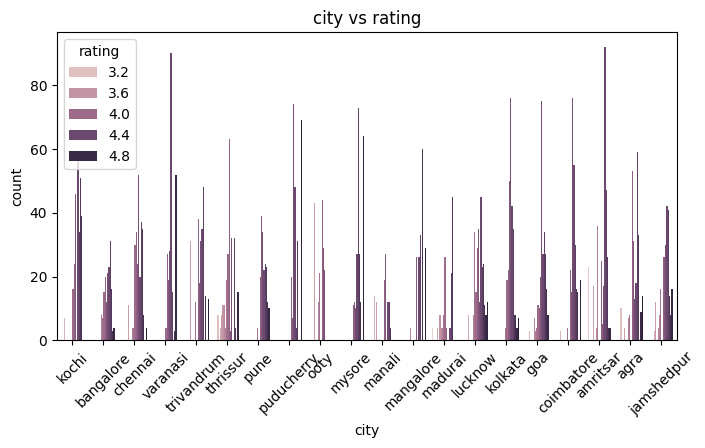

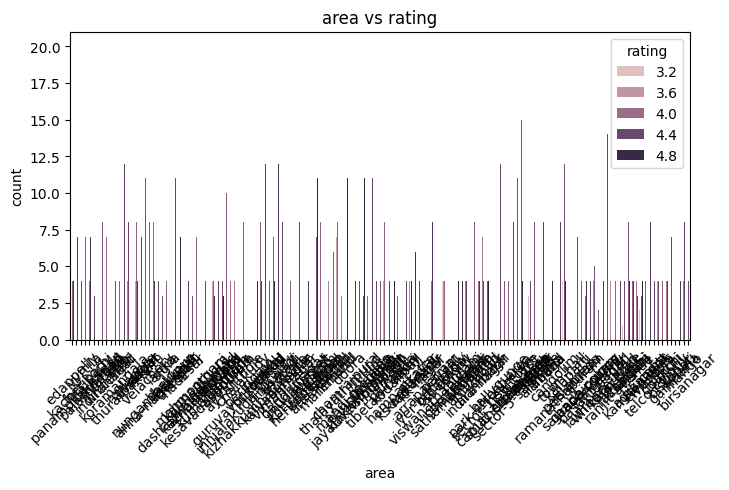

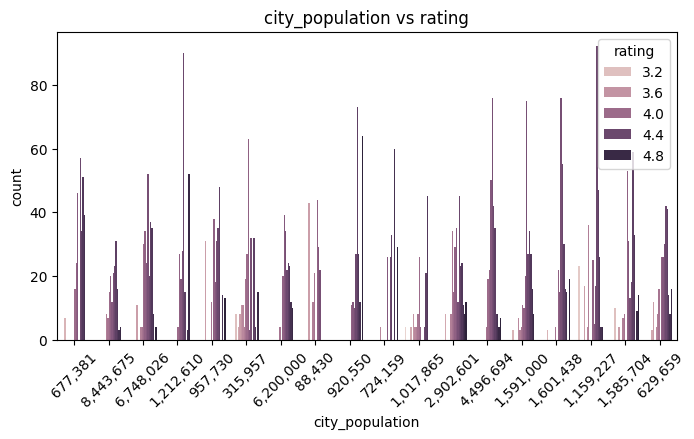

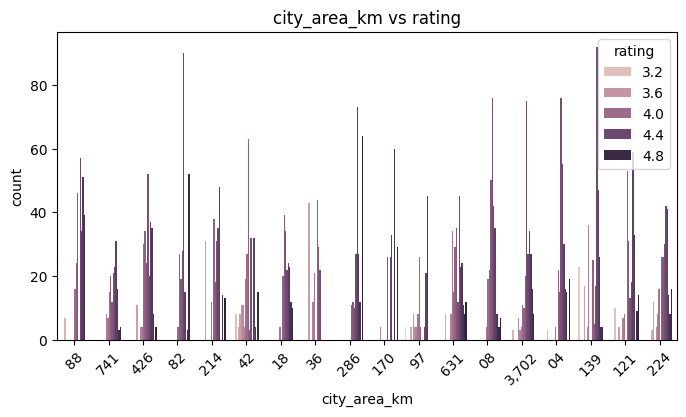

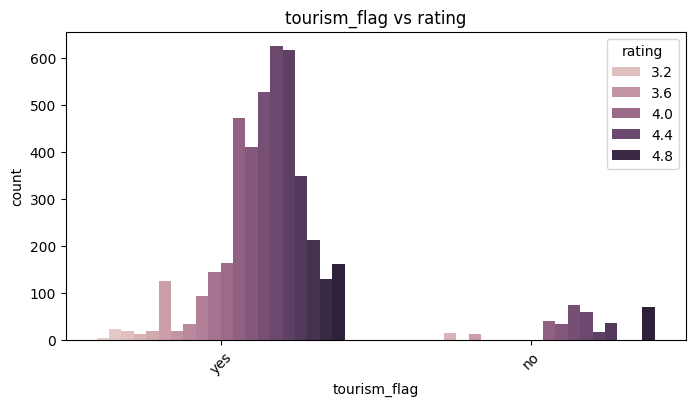

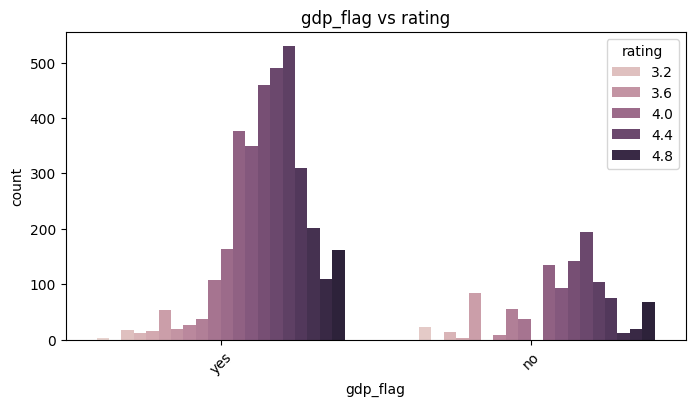

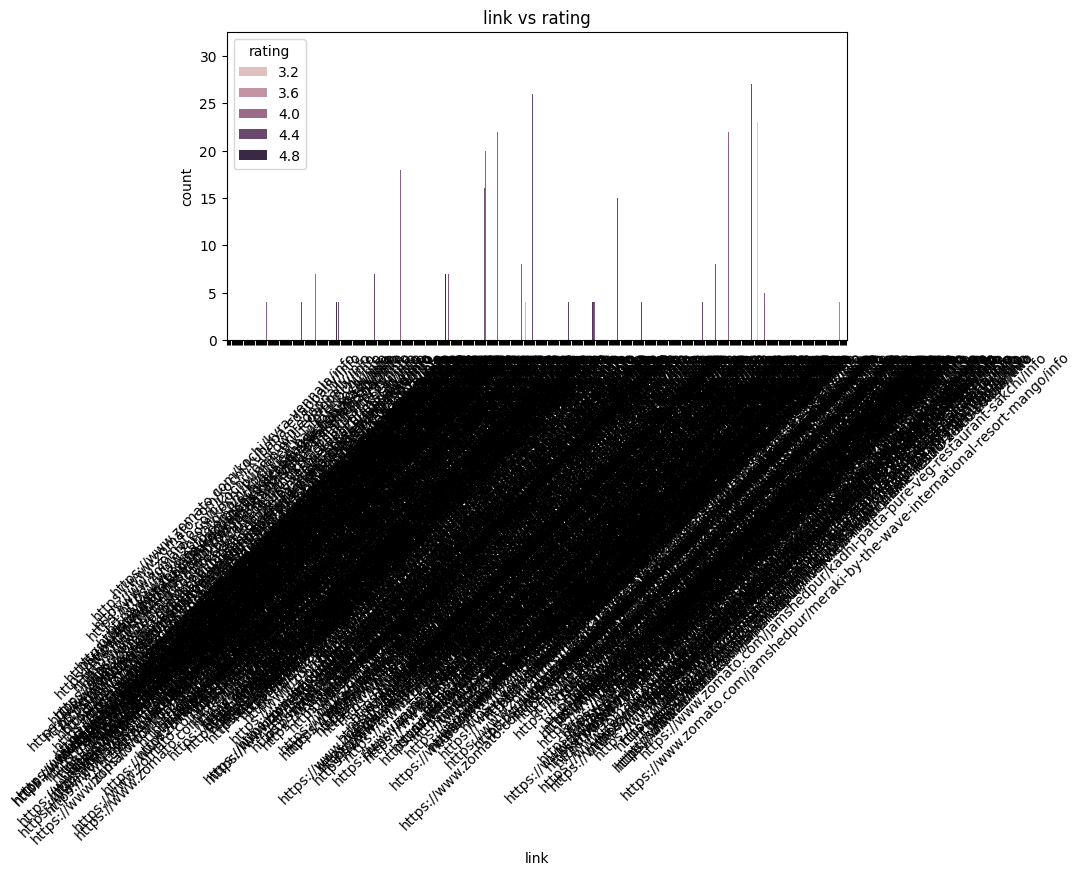

In [17]:
target = "rating"
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col], hue=df[target])
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation=45)
    plt.show()

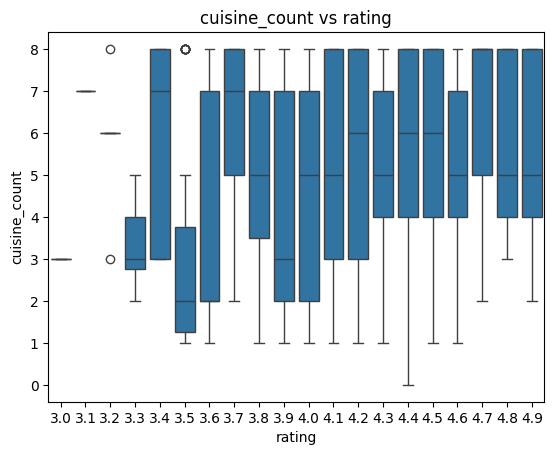

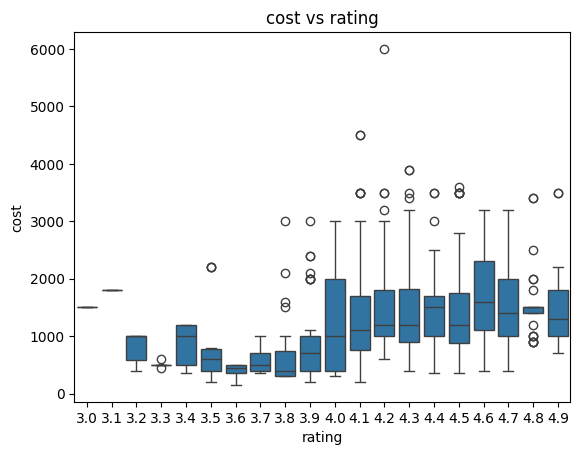

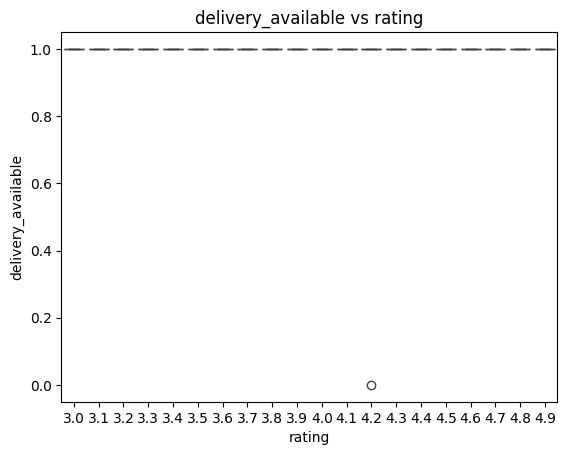

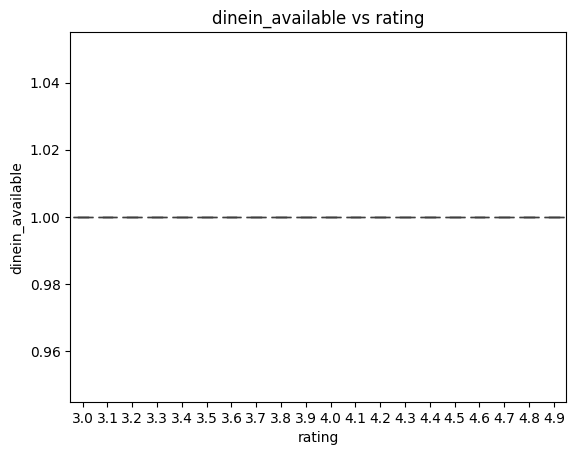

In [ ]:
target = "rating"

for col in num_cols:
    if col != target:
        plt.figure()
        sns.boxplot(x=df[target], y=df[col])
        plt.title(f"{col} vs {target}")
        plt.show()

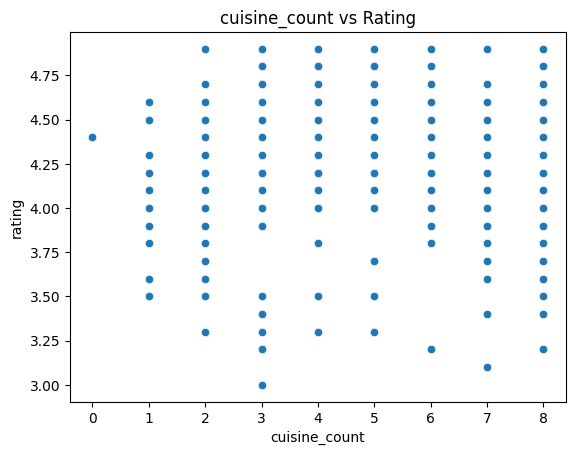

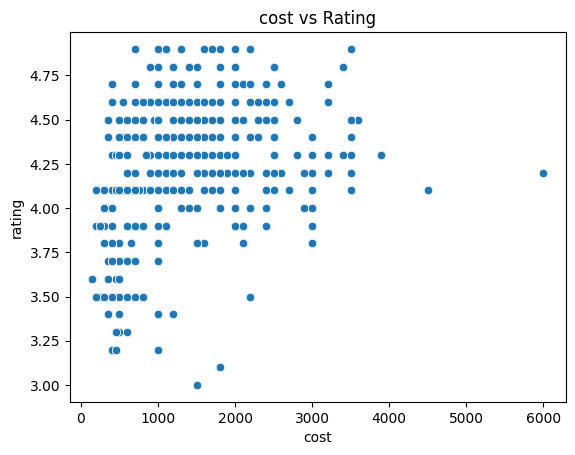

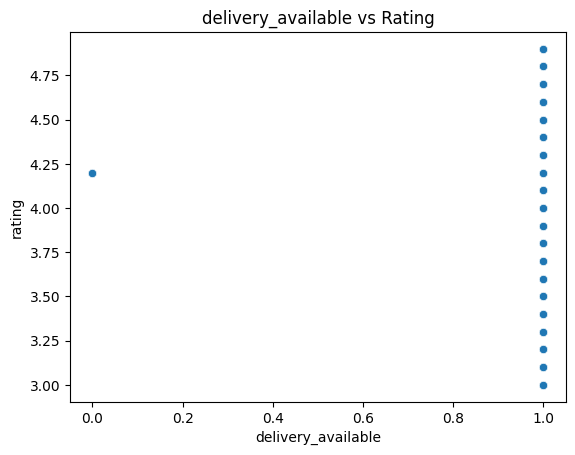

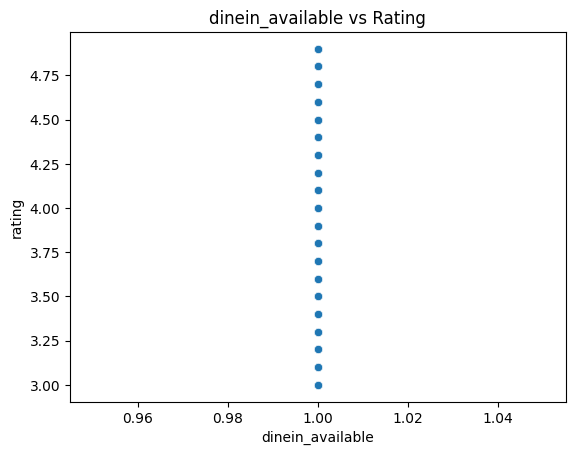

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    if col != "rating":
        plt.figure()
        sns.scatterplot(x=df[col], y=df["rating"])
        plt.title(f"{col} vs Rating")
        plt.show()

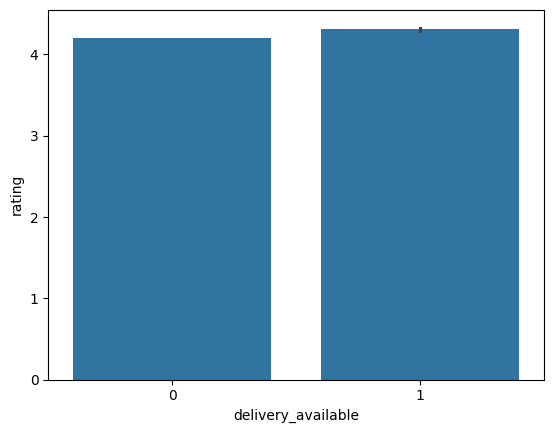

In [ ]:
sns.barplot(x=df["delivery_available"], y=df["rating"])
plt.show()

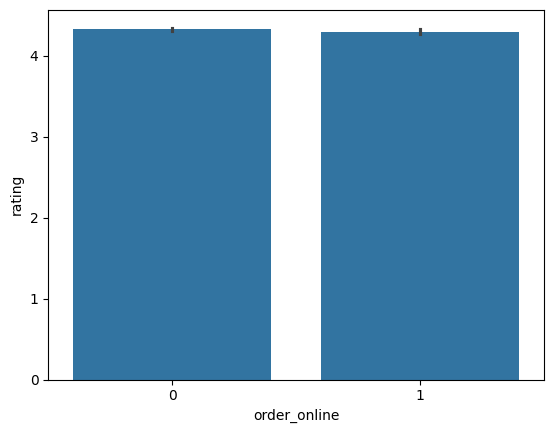

In [ ]:
sns.barplot(x=df["order_online"], y=df["rating"])
plt.show()

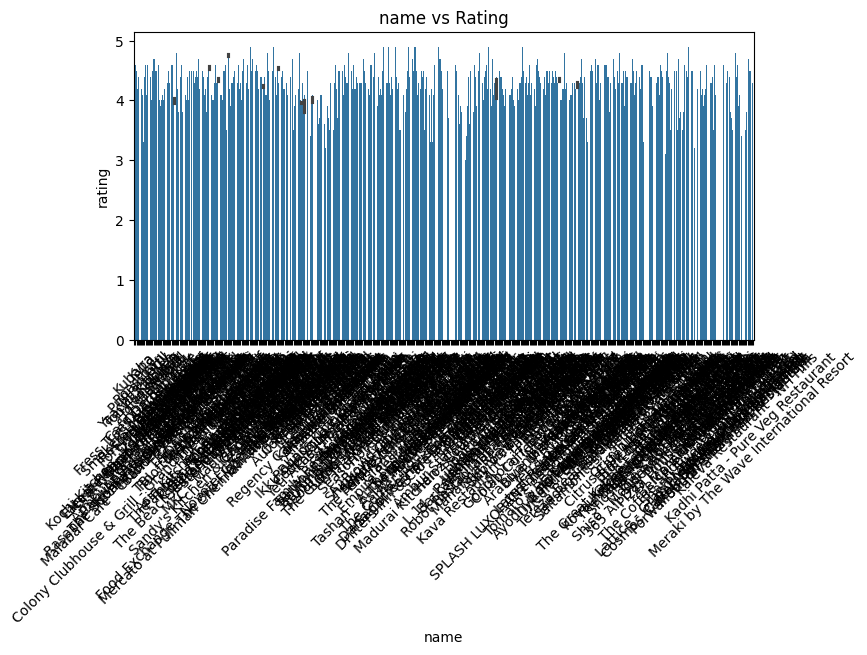

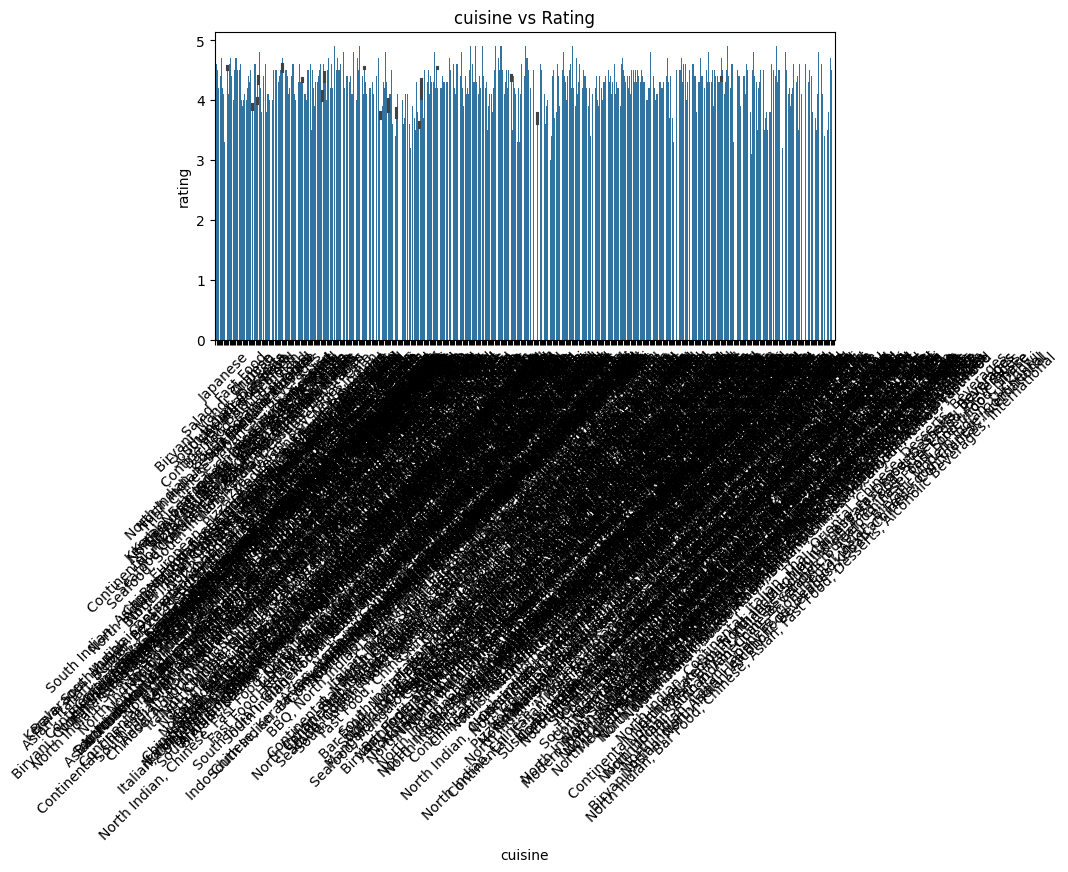

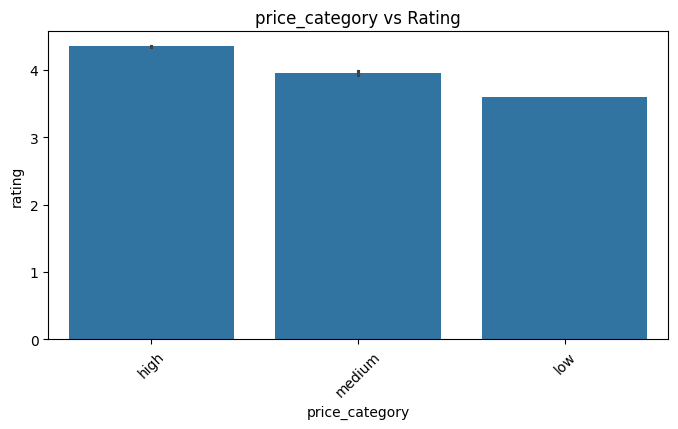

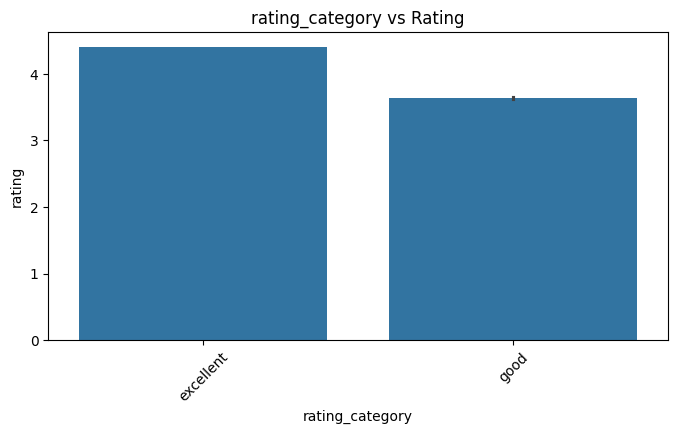

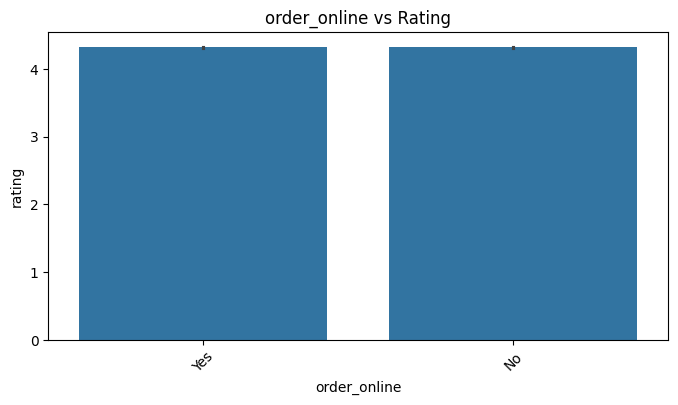

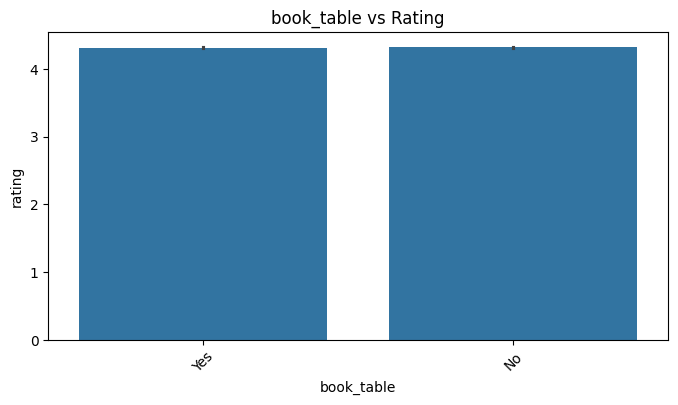

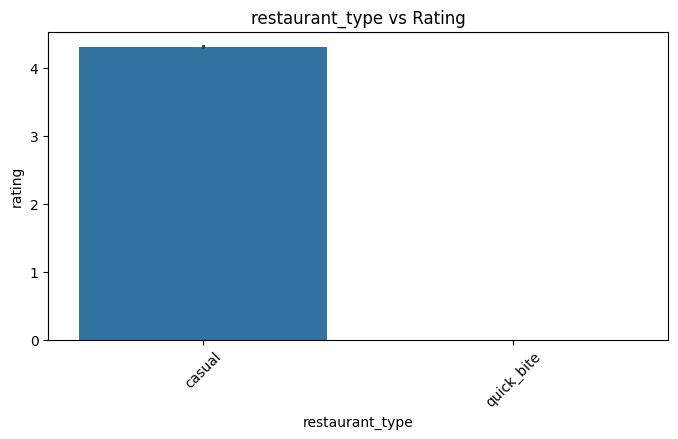

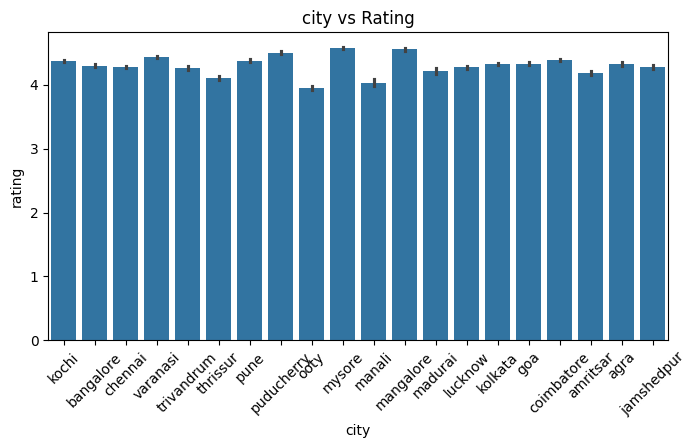

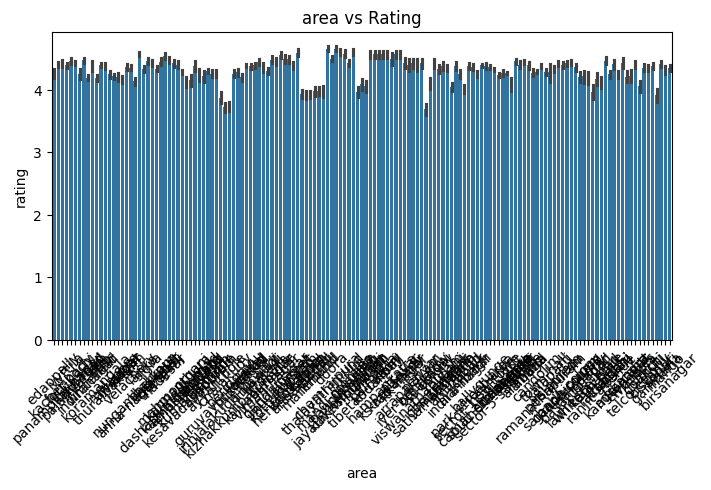

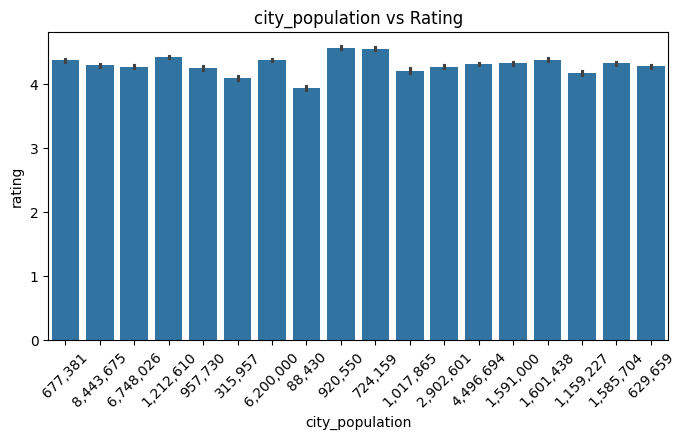

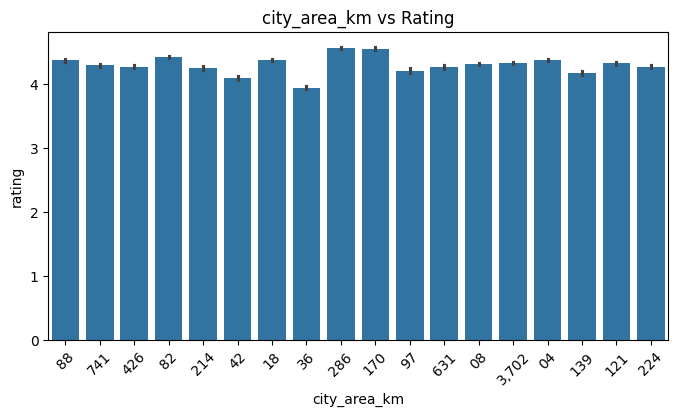

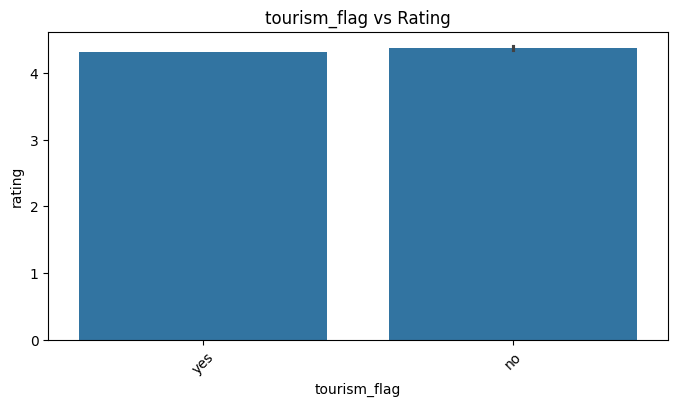

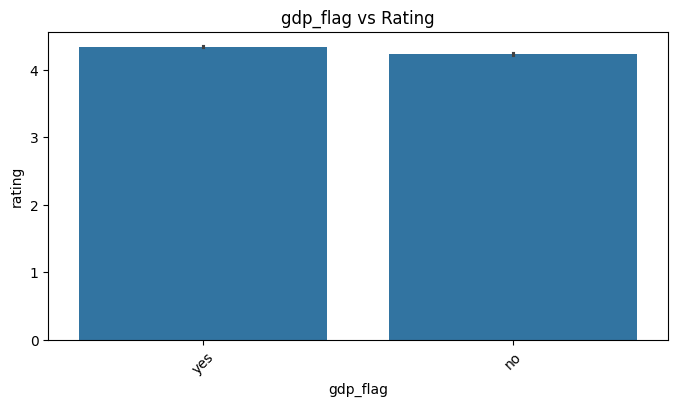

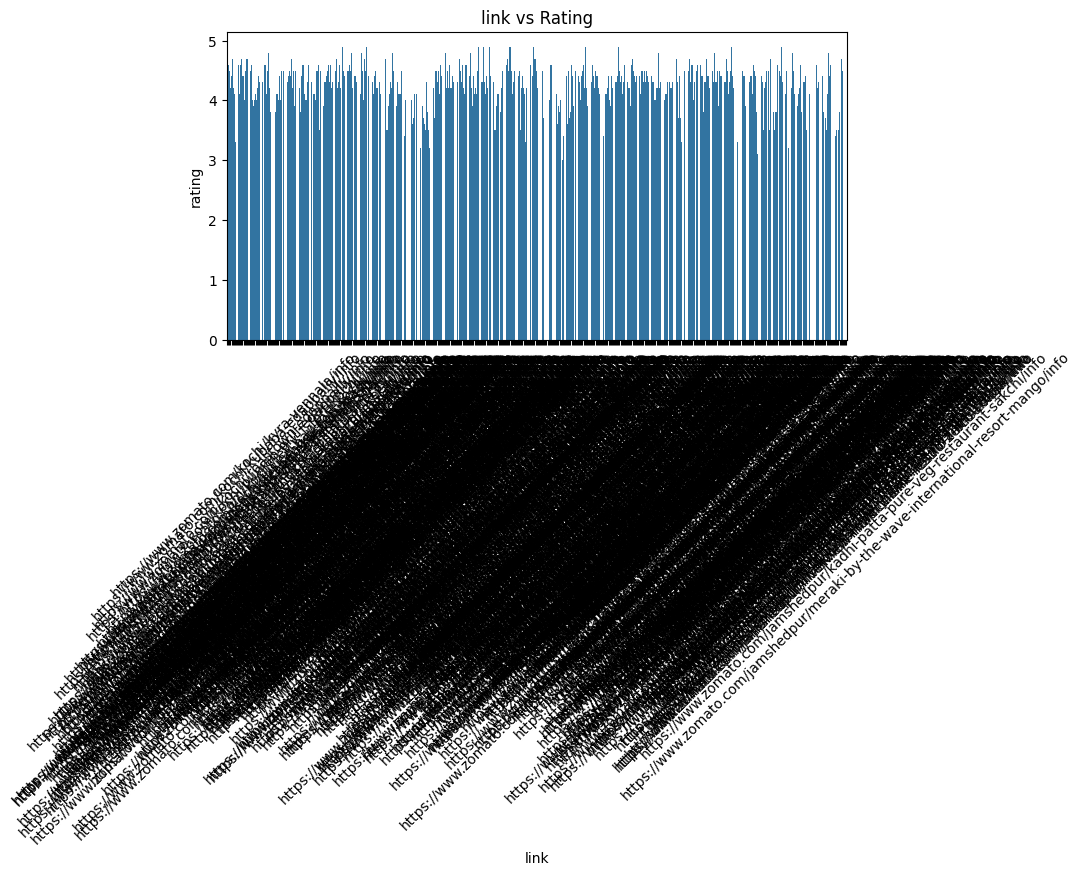

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.barplot(x=df[col], y=df["rating"])
    plt.title(f"{col} vs Rating")
    plt.xticks(rotation=45)
    plt.show()

In [18]:
print("\nCorrelation with target:")
corr = df.corr(numeric_only=True)
print(corr["rating"].sort_values(ascending=False))


Correlation with target:
rating                1.000000
cost                  0.230716
cuisine_count         0.177514
delivery_available    0.009936
dinein_available           NaN
Name: rating, dtype: float64


## Null Value Filling

In [19]:
df.isna().sum()

,0
name,0
cuisine,83
cuisine_count,0
cost,2
price_category,2
rating,541
rating_category,541
order_online,0
book_table,0
delivery_available,0


In [20]:
df["cuisine"] = df.groupby("area")["cuisine"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown")
)#most common cuisine per area

In [21]:
df["cost"] = df.groupby(["city"])["cost"].transform(
    lambda x: x.fillna(x.median())
)

In [22]:
def get_price_cat(x):
    if x < 200:
        return "low"
    elif x < 500:
        return "medium"
    else:
        return "high"

df["price_category"] = df["cost"].apply(get_price_cat)

In [23]:
df["rating"] = df.groupby(["restaurant_type","price_category","city"])["rating"].transform(
    lambda x: x.fillna(x.mean())
)

In [24]:
def rating_cat(x):
    if x >= 4:
        return "excellent"
    elif x >= 3:
        return "good"
    else:
        return "poor"

df["rating_category"] = df["rating"].apply(rating_cat)

In [25]:
#object --> float

df["city_population"] = (df["city_population"].astype(str).str.replace(",", "", regex=False))

df["city_area_km"] = (df["city_area_km"].astype(str).str.replace(",", "", regex=False))

# Convert to numeric
df["city_population"] = pd.to_numeric(df["city_population"], errors="coerce")
df["city_area_km"] = pd.to_numeric(df["city_area_km"], errors="coerce")

In [26]:
# Manali
df.loc[df["city"] == "manali", "city_population"] = 11700
df.loc[df["city"] == "manali", "city_area_km"] = 294

# Puducherry
df.loc[df["city"] == "puducherry", "city_population"] = 941000
df.loc[df["city"] == "puducherry", "city_area_km"] = 5503

In [27]:
df.isna().sum()

,0
name,0
cuisine,0
cuisine_count,0
cost,0
price_category,0
rating,9
rating_category,0
order_online,0
book_table,0
delivery_available,0


In [28]:
df["rating"].fillna(df["rating"].mean(), inplace=True)

/tmp/ipykernel_1475/3701116424.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["rating"].fillna(df["rating"].mean(), inplace=True)


In [29]:
df.isna().sum()

,0
name,0
cuisine,0
cuisine_count,0
cost,0
price_category,0
rating,0
rating_category,0
order_online,0
book_table,0
delivery_available,0


## Remove unwanted columns for ML

In [30]:
df_final = df.drop(columns=["name","link","rating_category","area"])

## Encoding

In [31]:
df_final

,cuisine,cuisine_count,cost,price_category,rating,order_online,book_table,delivery_available,dinein_available,restaurant_type,city,city_population,city_area_km,tourism_flag,gdp_flag
0,"Biryani, Mandi, Arabian",3,1000.0,high,4.4,Yes,Yes,1,1,casual,kochi,677381.0,88.0,yes,yes
1,"South Indian, Asian, North Indian, Continental...",6,2500.0,high,4.6,Yes,Yes,1,1,casual,kochi,677381.0,88.0,yes,yes
2,"Continental, Pizza, Beverages, Asian, Burger, ...",6,600.0,high,4.5,Yes,No,1,1,casual,kochi,677381.0,88.0,yes,yes
3,"Kerala, South Indian, Continental, Oriental, A...",8,1500.0,high,4.2,Yes,No,1,1,casual,kochi,677381.0,88.0,yes,yes
4,"North Indian, Kebab, Biryani, Mughlai",4,1700.0,high,4.4,No,Yes,1,1,casual,kochi,677381.0,88.0,yes,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13158,"North Indian, Chinese, Fast Food, Seafood, Mug...",5,600.0,high,4.3,Yes,Yes,1,1,casual,jamshedpur,629659.0,224.0,yes,no
13170,"North Indian, Continental, Italian, Thai, Orie...",8,1500.0,high,4.4,No,No,1,1,casual,jamshedpur,629659.0,224.0,yes,no
13176,"North Indian, Chinese, Fast Food, Seafood, Mug...",5,600.0,high,4.3,No,No,1,1,casual,jamshedpur,629659.0,224.0,yes,no
13177,"North Indian, Chinese, Continental, Sushi, Asi...",8,700.0,high,4.2,No,No,1,1,casual,jamshedpur,629659.0,224.0,yes,no


In [32]:
df_final.shape

(5059, 15)

In [33]:
df_final.dtypes

,0
cuisine,object
cuisine_count,int64
cost,float64
price_category,object
rating,float64
order_online,object
book_table,object
delivery_available,int64
dinein_available,int64
restaurant_type,object


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

In [35]:
numerical_cols = ["cuisine_count", "cost", "city_population", "city_area_km"]

categorical_cols = [ "cuisine","price_category","order_online", "book_table","restaurant_type", "city","delivery_available", "dinein_available","tourism_flag", "gdp_flag"]

In [36]:
df_final["order_online"] = df_final["order_online"].map({"Yes":1, "No":0})
df_final["book_table"] = df_final["book_table"].map({"Yes":1, "No":0})
df_final["tourism_flag"] = df_final["tourism_flag"].map({"yes":1, "no":0})
df_final["gdp_flag"] = df_final["gdp_flag"].map({"yes":1, "no":0})

In [37]:
numerical_cols = [
    "cuisine_count",
    "cost",
    "city_population",
    "city_area_km",
    "order_online",
    "book_table",
    "delivery_available",
    "dinein_available",
    "tourism_flag",
    "gdp_flag"
]

In [38]:
from sklearn.preprocessing import MultiLabelBinarizer

df_final["cuisine_list"] = df_final["cuisine"].apply(lambda x: [i.strip() for i in x.split(",")])

# top cusines
top_cuisines = df_final["cuisine_list"].explode().value_counts().head(20).index

df_final["cuisine_list"] = df_final["cuisine_list"].apply(
    lambda x: [i for i in x if i in top_cuisines]
)

#  MultiLabelBinarizer
mlb = MultiLabelBinarizer()
cuisine_encoded = mlb.fit_transform(df_final["cuisine_list"])

cuisine_df = pd.DataFrame(
    cuisine_encoded,
    columns=mlb.classes_,
    index=df.index
)

df_final = pd.concat([df_final, cuisine_df], axis=1)

# Drop original
df_final.drop(["cuisine", "cuisine_list"], axis=1, inplace=True)

In [39]:
df_final

,cuisine_count,cost,price_category,rating,order_online,book_table,delivery_available,dinein_available,restaurant_type,city,...,Fast Food,Italian,Kebab,Mughlai,North Indian,Pasta,Pizza,Seafood,Shake,South Indian
0,3,1000.0,high,4.4,1,1,1,1,casual,kochi,...,0,0,0,0,0,0,0,0,0,0
1,6,2500.0,high,4.6,1,1,1,1,casual,kochi,...,1,0,0,0,1,0,0,0,0,1
2,6,600.0,high,4.5,1,0,1,1,casual,kochi,...,0,0,0,0,0,0,1,0,0,0
3,8,1500.0,high,4.2,1,0,1,1,casual,kochi,...,0,1,0,0,0,0,0,0,0,1
4,4,1700.0,high,4.4,0,1,1,1,casual,kochi,...,0,0,1,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13158,5,600.0,high,4.3,1,1,1,1,casual,jamshedpur,...,1,0,0,1,1,0,0,1,0,0
13170,8,1500.0,high,4.4,0,0,1,1,casual,jamshedpur,...,0,1,0,0,1,0,0,0,0,0
13176,5,600.0,high,4.3,0,0,1,1,casual,jamshedpur,...,1,0,0,1,1,0,0,1,0,0
13177,8,700.0,high,4.2,0,0,1,1,casual,jamshedpur,...,0,0,1,0,1,0,0,0,0,0


In [40]:
onehot_cols = ["city", "restaurant_type"]
ordinal_cols = ["price_category"]

price_order = [["low", "medium", "high"]]

# Column Transformer

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), onehot_cols),

        ("ordinal", OrdinalEncoder(categories=price_order), ordinal_cols),

        ("num", "passthrough", numerical_cols)
    ],
    remainder="passthrough"

)

In [41]:
X = df_final.drop("rating", axis=1)
y = df_final["rating"]

X_encoded = preprocessor.fit_transform(X)

In [42]:
final_columns = preprocessor.get_feature_names_out()

df_encoded = pd.DataFrame(
    X_encoded.toarray() if hasattr(X_encoded, "toarray") else X_encoded,
    columns=final_columns
)
df_encoded

,onehot__city_agra,onehot__city_amritsar,onehot__city_bangalore,onehot__city_chennai,onehot__city_coimbatore,onehot__city_goa,onehot__city_jamshedpur,onehot__city_kochi,onehot__city_kolkata,onehot__city_lucknow,...,remainder__Fast Food,remainder__Italian,remainder__Kebab,remainder__Mughlai,remainder__North Indian,remainder__Pasta,remainder__Pizza,remainder__Seafood,remainder__Shake,remainder__South Indian
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5054,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
5055,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5056,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
5057,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
